In [1]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from causallearn.utils.cit import CIT
from sklearn.ensemble import RandomForestRegressor

try:
    from networkx.algorithms.d_separation import is_d_separator
except ImportError:
    from networkx.algorithms.d_separation import d_separated as is_d_separator

/home/s4517962/micromamba/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers

In [2]:
def markov_blanket_oracle_from_graph(G, observed_nodes, target):

    observed_nodes = list(observed_nodes)

    MB = []

    for v in observed_nodes:
        if v == target:
            continue

        conditioning_set = set(
            node for node in observed_nodes
            if node not in [target, v]
        )

        separated = is_d_separator(
            G,
            {target},
            {v},
            conditioning_set
        )

        if not separated:
            MB.append(v)

    return sorted(MB)

In [3]:
def estimate_true_effect_by_intervention(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
    beta=1.0,
    n_mc=100_000,
    rng=None,
    noise_scale=1.0,
):
    """
    Estimate the true causal effect contrast:

        E[Y | do(X=x1)] - E[Y | do(X=x0)]

    For linear SCMs (beta = 0), compute the exact total effect from the
    coefficient matrix. For nonlinear SCMs, use Monte Carlo intervention.
    """
    if beta == 0:
        order = graph_info["order"]
        B = graph_info["B"].loc[order, order].to_numpy(dtype=float)
        total_effect_matrix = np.linalg.inv(np.eye(len(order)) - B)

        x_idx = order.index(x)
        y_idx = order.index(y)
        effect_per_unit = total_effect_matrix[x_idx, y_idx]

        return float(effect_per_unit * (x1 - x0))

    if rng is None:
        rng = np.random.default_rng()

    # Use two child generators so the function is reproducible but independent.
    seed_0, seed_1 = rng.integers(0, 2**32 - 1, size=2)

    _, D0_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_0),
        noise_scale=noise_scale,
        intervention={x: x0},
        return_full=True,
    )

    _, D1_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_1),
        noise_scale=noise_scale,
        intervention={x: x1},
        return_full=True,
    )

    true_effect = D1_full[y].mean() - D0_full[y].mean()

    return true_effect


In [4]:
def estimate_effect_gformula(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
    model=None,
    random_state=0,
    estimator="auto",
    beta=None,
):
    """
    Estimate an adjustment effect using either a linear OLS estimator or a
    nonlinear random-forest g-formula estimator.

    If estimator="auto", use OLS when beta == 0 and random forest otherwise.
    """
    if Z is None:
        Z = []

    if x0 is None:
        x0 = D_obs[x].quantile(0.25)

    if x1 is None:
        x1 = D_obs[x].quantile(0.75)

    Z = list(Z)
    features = [x] + Z

    if estimator == "auto":
        estimator = "linear" if beta == 0 else "rf"

    if estimator == "linear":
        X_design = sm.add_constant(D_obs[features], has_constant="add")
        fitted = sm.OLS(D_obs[y], X_design).fit()
        return float(fitted.params[x] * (x1 - x0))

    if estimator != "rf":
        raise ValueError("estimator must be 'auto', 'linear', or 'rf'")

    if model is None:
        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(D_obs[features], D_obs[y])

    D_x0 = D_obs[features].copy()
    D_x1 = D_obs[features].copy()

    D_x0[x] = x0
    D_x1[x] = x1

    pred_x0 = model.predict(D_x0)
    pred_x1 = model.predict(D_x1)

    return float(np.mean(pred_x1 - pred_x0))


In [5]:
def ci_test(X, Y, Z, D_obs, alpha=0.05, method="kci"):
    """
    Returns True if X and Y are conditionally independent given Z, False otherwise.

    This version uses causal-learn's implemented CI tests.

    Recommended methods:
        method="kci"      -> nonlinear continuous CI test
        method="fisherz"  -> linear Gaussian CI test, useful for sanity checks

    Parameters
    ----------
    X, Y : str
        Variable names.
    Z : list
        Conditioning set.
    D_obs : pd.DataFrame
        Observed data.
    alpha : float
        Significance level. We return independence when p_value > alpha.
    method : str
        causal-learn CI test name, usually "kci" or "fisherz".

    Returns
    -------
    indep : bool
        True if independent, False if dependent.
    p_value : float
        CI test p-value.
    stat : float
        Test statistic. causal-learn's CIT interface returns p-values,
        so stat is set to np.nan for compatibility with your existing code.
    """
    Z = list(Z)

    columns = D_obs.columns.tolist()
    col_to_idx = {col: i for i, col in enumerate(columns)}

    X_idx = col_to_idx[X]
    Y_idx = col_to_idx[Y]
    Z_idx = [col_to_idx[z] for z in Z]

    data_np = D_obs.to_numpy(dtype=float)

    cache_key = (id(D_obs), method)

    if not hasattr(ci_test, "_cit_cache"):
        ci_test._cit_cache = {}

    if cache_key not in ci_test._cit_cache:
        ci_test._cit_cache[cache_key] = CIT(data_np, method)

    cit_obj = ci_test._cit_cache[cache_key]

    p_value = cit_obj(X_idx, Y_idx, Z_idx)

    indep = p_value > alpha

    return indep, p_value

In [6]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [7]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [8]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval
    }

In [9]:
def simulate_nonlinear_scm(
    graph_info,
    n,
    beta=1.0,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):
    """
    Simulate data from a nonlinear SCM.

    For each node i:

        eta_i = sum_{j in Pa(i)} b_{ji} X_j

        X_i = (1 - beta) * eta_i + beta * tanh(eta_i) + epsilon_i

    beta = 0 gives the linear Gaussian SCM.
    beta = 1 gives the fully tanh nonlinear SCM.

    Parameters
    ----------
    graph_info : dict
        Output from generate_random_dag().
    n : int
        Number of samples.
    beta : float
        Nonlinearity strength in [0, 1].
    rng : np.random.Generator
        Random number generator.
    noise_scale : float
        Standard deviation of Gaussian noise.
    intervention : dict or None
        Example: {"X": 1.0}. If given, the specified variable is fixed
        to that value during simulation.
    return_full : bool
        If True, return both observed and full data.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed data only.
    D_full : pd.DataFrame, optional
        Full data including latent variables, returned only if return_full=True.
    """
    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs

## Generate synthetic data

In [10]:
def generate_random_nonlinear_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    p=0.10,
    beta=1,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):
    """
    Generate a random DAG with observed and latent variables, simulate nonlinear data,
    remove latent variables from the observed dataset, and estimate the true causal
    effect by intervention.
    The neighborhood size is determined only by the random graph probability p.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed simulated data, excluding latent variables.

    B : pd.DataFrame
        Full coefficient matrix including latent variables.

    true_ce : float
        True nonlinear causal effect estimated by intervention.

    graph_info : dict
        Full graph metadata.

    D_full : pd.DataFrame, optional
        Full simulated data including latent variables, returned only if return_full=True.
    """

    if rng is None:
        rng = np.random.default_rng()

    # ============================================================
    # 1. Generate random DAG
    # ============================================================

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    # Pretreatment order:
    # all latent and observed covariates are before X and Y.
    # Therefore X/Y cannot cause observed covariates.
    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                # Random edges are allowed into X and Y from background nodes.
                # This allows latent variables to be real unobserved causes/confounders.
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    edges = list(dict.fromkeys(edges))

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # ============================================================
    # 2. Compute oracle Markov blankets for diagnostics
    # ============================================================
    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,

        # Kept for compatibility with old downstream code.
        "n_force_x_parents": 0,
        "n_force_y_parents": 0,
        "forced_x_parents": [],
        "forced_y_parents": [],
        "forced_local_edges": [],
        "n_force_latent_x_parents": 0,
        "n_force_latent_y_parents": 0,
        "n_force_latent_xy_parents": 0,
        "forced_latent_x_parents": [],
        "forced_latent_y_parents": [],
        "forced_latent_xy_parents": [],
        "forced_latent_edges": [],

        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    # ============================================================
    # 3. Simulate nonlinear SCM
    # ============================================================

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values

        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    # Observed dataset: remove latent variables.
    D_obs = D_full[observed_nodes].copy()

    # ============================================================
    # 4. Estimate true causal effect by intervention
    # ============================================================

    x0 = -1.0
    x1 = 1.0

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info

In [11]:
def generate_random_nonlinear_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    p=0.10,
    beta=1,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):
    """
    Generate a random DAG with observed and latent variables, simulate nonlinear data,
    remove latent variables from the observed dataset, and estimate the true causal
    effect by intervention.

    This version removes the forced X/Y parent controls.
    The neighborhood size is determined only by the random graph probability p.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed simulated data, excluding latent variables.

    B : pd.DataFrame
        Full coefficient matrix including latent variables.

    true_ce : float
        True nonlinear causal effect estimated by intervention.

    graph_info : dict
        Full graph metadata.

    D_full : pd.DataFrame, optional
        Full simulated data including latent variables, returned only if return_full=True.
    """

    if rng is None:
        rng = np.random.default_rng()

    # ============================================================
    # 1. Generate random DAG
    # ============================================================

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    # Pretreatment order:
    # all latent and observed covariates are before X and Y.
    # Therefore X/Y cannot cause observed covariates.
    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    edges = list(dict.fromkeys(edges))

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # ============================================================
    # 2. Compute oracle Markov blankets for diagnostics
    # ============================================================


    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    # ============================================================
    # 3. Simulate nonlinear SCM
    # ============================================================

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values

        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    # ============================================================
    # 4. Estimate true causal effect by intervention
    # ============================================================

    x0 = -1.0
    x1 = 1.0

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info

## Main Algorithms

### EHS

In [12]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.15, max_z_size=None, x0=None, x1=None, beta=None, estimator='auto'):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z, x0=x0, x1=x1, beta=beta, estimator=estimator) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

### LPC-ID


In [13]:
def alg_ea_pc(D_obs, x='X', y='Y', max_z_size= None, alpha_pc=0.1, alpha_dep=0.01, alpha_indep=0.15, ci_method='kci', x0=None, x1=None, beta=None, estimator='auto'):
    
    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    pc_max_cond_size = len(skeleton.nodes) - 2

    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    indep, p_value = ci_test(A, B, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key] = p_value
                    ci_cache[(B, A, Z)] = p_value

                p_value = ci_cache[key]

                indep_pc = p_value > alpha_pc

                # Entner-style conservative decisions
                dep_entner = p_value < alpha_dep
                indep_entner = p_value > alpha_indep

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Rule 2a
                if pair_is_xy and indep_entner:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # Rule 1 hook
                if pair_is_wy and dep_entner and (x not in Z):
                    w = A if A in W else B

                    if w not in Z and y not in Z:
                        Z_plus_x = tuple(sorted(list(Z) + [x]))
                        key_r1 = (w, y, Z_plus_x)

                        n_ci_requests += 1

                        if key_r1 not in ci_cache:
                            n_ci_executed += 1
                            _, p_r1_followup = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                            ci_cache[key_r1] = p_r1_followup
                            ci_cache[(y, w, Z_plus_x)] = p_r1_followup

                        p_r1_followup = ci_cache[key_r1]

                        if p_r1_followup > alpha_indep:
                            r1_count += 1
                            r1_hits.append({
                                "reason": "R1",
                                "w": w,
                                "Z": list(Z)
                            })

                # Rule 2 hook from cache
                if pair_is_wy and indep_entner:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and dep_entner:
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                # Standard PC skeleton update
                if indep_pc and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)
                    break


        if not any_test_possible_this_round:
            break

    # Run remaining LSAS tests
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    MB_y = sorted(Ne_y - {x})
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)

            n_ci_requests += 1

            if key_xy not in ci_cache:
                n_ci_executed += 1
                _, p_xy = ci_test(x, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                ci_cache[key_xy] = p_xy
                ci_cache[(y, x, Z)] = p_xy

            p_xy = ci_cache[key_xy]

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z)
                })

    # R1

    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                dep_wy = p_wy < alpha_dep

                if dep_wy:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x not in ci_cache:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[(y, w, Z_plus_x)] = p_wy_x

                    p_wy_x = ci_cache[key_wy_x]

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z)
                        })
                
                #R2ii)
                key_wx = (w, x, Z)

                n_ci_requests += 1

                if key_wx not in ci_cache:
                    n_ci_executed += 1
                    _, p_wx = ci_test(w, x, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wx] = p_wx
                    ci_cache[(x, w, Z)] = p_wx

                p_wx = ci_cache[key_wx]

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z)
                    })


    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs, x=x, y=y, Z=Z,
                x0=x0, x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
    }

In [14]:
def alg_ea_pc_local(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    max_pc_cond_size=None,
    alpha_pc=0.40,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    use_pc_stable=True,
    collect_pc_entner_hits=True,
):
    """
    Local Entner-aware PC for X -> Y under:
      - causal sufficiency / no latent variables
      - all covariates are pre-treatment
      - Y is not an ancestor of X
      - X and Y are not ancestors of covariates

    The algorithm does not initialize a full graph.
    It only initializes a local working graph with edges:
      X--W, Y--W, and X--Y.

    It then runs local PC deletion only on edges incident to X or Y,
    collects Entner-style evidence during PC, and finally runs a
    local LSAS-style completion over the recovered local neighborhoods.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    if alpha_pc < alpha_indep:
        print(
            "Warning: alpha_pc < alpha_indep. "
            "PC may delete edges using weaker independence evidence than the rule system accepts."
        )

    # ------------------------------------------------------------------
    # Local working skeleton: star around X and Y only
    # ------------------------------------------------------------------
    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for w in W:
        skeleton.add_edge(x, w)
        skeleton.add_edge(y, w)

    skeleton.add_edge(x, y)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    # ------------------------------------------------------------------
    # Cached CI helper
    # ------------------------------------------------------------------
    def canonical_key(A, B, Z):
        Z = tuple(sorted(Z))
        if str(A) <= str(B):
            return (A, B, Z)
        else:
            return (B, A, Z)

    def get_pvalue(A, B, Z):
        nonlocal n_ci_requests, n_ci_executed

        Z = tuple(sorted(Z))
        key = canonical_key(A, B, Z)

        n_ci_requests += 1

        if key not in ci_cache:
            n_ci_executed += 1
            _, p_value = ci_test(
                A, B, list(Z),
                D_obs,
                alpha=alpha_pc,
                method=ci_method
            )
            ci_cache[key] = p_value

        return ci_cache[key]

    def z_allowed_for_rules(Z):
        return max_z_size is None or len(Z) <= max_z_size

    def add_r1_hit(reason, w, Z):
        nonlocal r1_count
        Z_list = list(Z)
        hit = {"reason": reason, "w": w, "Z": Z_list}
        r1_hits.append(hit)
        r1_count += 1

    def add_r2_hit(reason, Z, w=None):
        nonlocal r2_count
        hit = {"reason": reason, "Z": list(Z)}
        if w is not None:
            hit["w"] = w
        r2_hits.append(hit)
        r2_count += 1

    # ------------------------------------------------------------------
    # Entner-aware hooks during PC
    # ------------------------------------------------------------------
    def collect_entner_hooks(A, B, Z, p_value):
        """
        Use the CI test A _||_ B | Z observed during local PC
        to collect Entner-style evidence.

        This is optional acceleration/evidence collection.
        The final LSAS-style completion below is still the main rule checker.
        """
        Z = tuple(sorted(Z))

        if not z_allowed_for_rules(Z):
            return

        dep_entner = p_value < alpha_dep
        indep_entner = p_value > alpha_indep

        pair_is_xy = set([A, B]) == set([x, y])
        pair_is_wy = ((A in W and B == y) or (B in W and A == y))
        pair_is_wx = ((A in W and B == x) or (B in W and A == x))

        # R2a: X independent Y | Z
        if pair_is_xy and indep_entner:
            add_r2_hit("R2a_PC", Z)

        # R1: w dep Y | Z and w indep Y | Z + X
        if pair_is_wy and dep_entner and x not in Z:
            w = A if A in W else B

            if w not in Z and y not in Z:
                Z_plus_x = tuple(sorted(list(Z) + [x]))
                p_wy_x = get_pvalue(w, y, Z_plus_x)

                if p_wy_x > alpha_indep:
                    add_r1_hit("R1_PC", w, Z)

        # R2b: w dep X | Z and w indep Y | Z
        # Do not rely on whether the counterpart test is already cached.
        # Explicitly request it via get_pvalue.
        if pair_is_wy and indep_entner:
            w = A if A in W else B

            if w not in Z and x not in Z and y not in Z:
                p_wx = get_pvalue(w, x, Z)

                if p_wx < alpha_dep:
                    add_r2_hit("R2b_PC", Z, w=w)

        if pair_is_wx and dep_entner:
            w = A if A in W else B

            if w not in Z and x not in Z and y not in Z:
                p_wy = get_pvalue(w, y, Z)

                if p_wy > alpha_indep:
                    add_r2_hit("R2b_PC", Z, w=w)

    # ------------------------------------------------------------------
    # Local PC phase
    # ------------------------------------------------------------------
    if max_pc_cond_size is None:
        # With local star initialization this can be large at l=0.
        # For 500 nodes, you probably want max_pc_cond_size=2 or 3.
        pc_max_cond_size = len(W)
    else:
        pc_max_cond_size = max_pc_cond_size

    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        edges_to_remove = []

        if use_pc_stable:
            adj_snapshot = {
                node: set(skeleton.neighbors(node))
                for node in skeleton.nodes
            }
        else:
            adj_snapshot = None

        # Only local edges matter: X--*, Y--*
        pairs_to_check = [
            (A, B)
            for A, B in list(skeleton.edges())
            if x in (A, B) or y in (A, B)
        ]

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            if use_pc_stable:
                adjA = list(adj_snapshot[A] - {B})
                adjB = list(adj_snapshot[B] - {A})
            else:
                adjA = [n for n in skeleton.neighbors(A) if n != B]
                adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))

                p_value = get_pvalue(A, B, Z)

                if collect_pc_entner_hits:
                    collect_entner_hooks(A, B, Z, p_value)

                indep_pc = p_value > alpha_pc

                if indep_pc:
                    edges_to_remove.append((A, B, Z))
                    break

        for A, B, Z in edges_to_remove:
            if skeleton.has_edge(A, B):
                skeleton.remove_edge(A, B)
                sepsets[frozenset([A, B])] = list(Z)

        if not any_test_possible_this_round:
            break

    # ------------------------------------------------------------------
    # Construct local Markov blanket candidates
    # ------------------------------------------------------------------
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    # Under pre-treatment, Y has no children, so MB(Y) = Adj(Y).
    MB_y = sorted(Ne_y - {x})

    # If X--Y remains, X may have child Y, so parents of Y are spouses of X.
    # Under pre-treatment, those are captured by Ne_y.
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    # ------------------------------------------------------------------
    # LSAS-style completion over recovered local candidates
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a completion: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):
            Z = tuple(sorted(Z))

            p_xy = get_pvalue(x, y, Z)

            if p_xy > alpha_indep:
                add_r2_hit("R2a_LSAS_completion", Z)

    # R1 and R2b completion
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):
                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # R1: w dep Y | Z and w indep Y | Z + X
                p_wy = get_pvalue(w, y, Z)

                if p_wy < alpha_dep:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    p_wy_x = get_pvalue(w, y, Z_plus_x)

                    if p_wy_x > alpha_indep:
                        add_r1_hit("R1_LSAS_completion", w, Z)

                # R2b: w dep X | Z and w indep Y | Z
                p_wx = get_pvalue(w, x, Z)

                # Reuse p_wy from above.
                if p_wx < alpha_dep and p_wy > alpha_indep:
                    add_r2_hit("R2b_LSAS_completion", Z, w=w)

    # ------------------------------------------------------------------
    # Decision rule: match LSAS repo priority, R1 before R2
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Ne_x": sorted(Ne_x),
        "Ne_y": sorted(Ne_y),
        "xy_adjacent": xy_adjacent,
        "local_edges_remaining": list(skeleton.edges()),
        "ci_cache_size": len(ci_cache),
    }

In [15]:
def alg_ea_pc_local_clean(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    max_pc_cond_size=None,
    alpha_pc=0.40,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    use_pc_stable=True,
):
    """
    Local PC + Entner/LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    This version does NOT initialize the full graph.
    It only initializes local candidate edges:
      X--W, Y--W, and X--Y.

    It also does NOT collect Entner evidence during PC.
    Entner/LSAS rules are checked only after local MB recovery.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    if alpha_pc < alpha_indep:
        print(
            "Warning: alpha_pc < alpha_indep. "
            "PC may delete edges using weaker independence evidence than the rule system accepts."
        )

    # ------------------------------------------------------------------
    # Local working skeleton: only X--W, Y--W, and X--Y
    # ------------------------------------------------------------------
    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for w in W:
        skeleton.add_edge(x, w)
        skeleton.add_edge(y, w)

    skeleton.add_edge(x, y)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_pc_cond_size is None:
        pc_max_cond_size = len(W)
    else:
        pc_max_cond_size = max_pc_cond_size

    # ------------------------------------------------------------------
    # Local PC phase
    # ------------------------------------------------------------------
    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        edges_to_remove = []

        if use_pc_stable:
            adj_snapshot = {
                node: set(skeleton.neighbors(node))
                for node in skeleton.nodes
            }
        else:
            adj_snapshot = None

        pairs_to_check = [
            (A, B)
            for A, B in list(skeleton.edges())
            if x in (A, B) or y in (A, B)
        ]

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            if use_pc_stable:
                adjA = list(adj_snapshot[A] - {B})
                adjB = list(adj_snapshot[B] - {A})
            else:
                adjA = [n for n in skeleton.neighbors(A) if n != B]
                adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))

                key = (A, B, Z)
                rev_key = (B, A, Z)

                n_ci_requests += 1

                if key in ci_cache:
                    p_value = ci_cache[key]
                elif rev_key in ci_cache:
                    p_value = ci_cache[rev_key]
                    ci_cache[key] = p_value
                else:
                    n_ci_executed += 1
                    _, p_value = ci_test(
                        A,
                        B,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key] = p_value
                    ci_cache[rev_key] = p_value

                if p_value > alpha_pc:
                    edges_to_remove.append((A, B, Z))
                    break

        for A, B, Z in edges_to_remove:
            if skeleton.has_edge(A, B):
                skeleton.remove_edge(A, B)
                sepsets[frozenset([A, B])] = list(Z)

        if not any_test_possible_this_round:
            break

    # ------------------------------------------------------------------
    # Construct local Markov blanket candidates
    # ------------------------------------------------------------------
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    MB_y = sorted(Ne_y - {x})

    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_pc,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # ------------------------------------------------------
                # Test w _||_ Y | Z
                # ------------------------------------------------------
                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # ------------------------------------------------------
                # R1: w dependent Y | Z and w independent Y | Z + X
                # ------------------------------------------------------
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_pc,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # ------------------------------------------------------
                # R2b: w dependent X | Z and w independent Y | Z
                # ------------------------------------------------------
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style priority, R1 before R2
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Ne_x": sorted(Ne_x),
        "Ne_y": sorted(Ne_y),
        "xy_adjacent": xy_adjacent,
        "local_edges_remaining": list(skeleton.edges()),
        "ci_cache_size": len(ci_cache),
    }

In [16]:
def alg_ea_iamb(
    D_obs,
    x='X',
    y='Y',
    max_z_size=None,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method='kci',
    x0=None,
    x1=None,
    beta=None,
    estimator='auto',
):
    """
    Entner-aware IAMB + LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    IAMB is used to recover MB(Y) and MB(X).
    During IAMB tests, Entner-style R1/R2 evidence is collected on the fly.
    After MB recovery, the usual LSAS-style completion is run over the recovered blankets.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    ci_cache = {}
    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    # ------------------------------------------------------------------
    # IAMB for target Y
    # ------------------------------------------------------------------
    target = y
    CMB_y = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_y]

        for v in candidates:
            Z = tuple(sorted(CMB_y))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y",
                        "Z": list(Z),
                    })

                # R1: w dependent Y | Z and w independent Y | Z + X
                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_y.append(best_var)
        else:
            break

    # Backward phase for Y
    changed = True

    while changed:
        changed = False

        for v in list(CMB_y):
            Z = tuple(sorted([node for node in CMB_y if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_y.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # IAMB for target X
    # ------------------------------------------------------------------
    target = x
    CMB_x = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_x]

        for v in candidates:
            Z = tuple(sorted(CMB_x))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X",
                        "Z": list(Z),
                    })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_x.append(best_var)
        else:
            break

    # Backward phase for X
    changed = True

    while changed:
        changed = False

        for v in list(CMB_x):
            Z = tuple(sorted([node for node in CMB_x if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_x.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # Construct recovered Markov blanket candidates
    # ------------------------------------------------------------------
    raw_MB_y = set(CMB_y)
    raw_MB_x = set(CMB_x)

    xy_adjacent = (x in raw_MB_y) or (y in raw_MB_x)

    MB_y = sorted(raw_MB_y - {x, y})

    if xy_adjacent:
        MB_x = sorted((raw_MB_x | raw_MB_y) - {x, y})
    else:
        MB_x = sorted(raw_MB_x - {x, y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # R1: w dependent Y | Z and w independent Y | Z + X
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style R1 priority
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "raw_MB_x": sorted(raw_MB_x),
        "raw_MB_y": sorted(raw_MB_y),
        "MB_x": MB_x,
        "MB_y": MB_y,
        "xy_adjacent": xy_adjacent,
        "ci_cache_size": len(ci_cache),
    }

In [17]:
def alg_ea_pc_fmmb(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    max_adj_cond_size=2,
    max_path_len=1,
    max_shrink_z_size=3,
    max_mmb_size=None,
):
    """
    EA-FMMB:
      FMMB-style MAG Markov blanket discovery for X and Y
      followed by Entner/LSAS completion.

    Intended for settings with possible latent confounders.
    The output MMB_x and MMB_y are candidate MAG Markov blankets.

    This is a bounded practical version:
      - max_adj_cond_size controls adjacency discovery.
      - max_path_len controls recursive attached-set path depth.
      - max_shrink_z_size controls shrink conditioning-set size.
      - max_mmb_size optionally stops expansion if the blanket grows too large.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    raw_MMB = {}
    raw_PC = {}
    raw_AS = {}
    raw_Sep = {}

    # ------------------------------------------------------------------
    # FMMB-style discovery for target Y and target X
    # ------------------------------------------------------------------
    for target in [y, x]:

        candidates_all = [node for node in observed_nodes if node != target]

        # --------------------------------------------------------------
        # Stage 1: PC_T / Adj_T discovery
        # --------------------------------------------------------------
        PC_T = set(candidates_all)
        Sep_T = {}
        removed_any_level = True

        for l in range(max_adj_cond_size + 1):

            if len(PC_T) <= l:
                break

            removed_this_level = []

            for v in list(PC_T):

                if v not in PC_T:
                    continue

                cond_pool = sorted(list(PC_T - {v}))

                if len(cond_pool) < l:
                    continue

                found_sep = False

                for Z in itertools.combinations(cond_pool, l):

                    Z = tuple(sorted(Z))

                    key = (v, target, Z)
                    rev_key = (target, v, Z)

                    n_ci_requests += 1

                    if key in ci_cache:
                        p_value = ci_cache[key]
                    elif rev_key in ci_cache:
                        p_value = ci_cache[rev_key]
                        ci_cache[key] = p_value
                    else:
                        n_ci_executed += 1
                        _, p_value = ci_test(
                            v,
                            target,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key] = p_value
                        ci_cache[rev_key] = p_value

                    if p_value > alpha_indep:
                        found_sep = True
                        Sep_T[v] = list(Z)
                        sepsets[frozenset([v, target])] = list(Z)
                        break

                if found_sep:
                    removed_this_level.append(v)

            for v in removed_this_level:
                if v in PC_T:
                    PC_T.remove(v)

            if len(removed_this_level) == 0 and l > len(PC_T):
                break

        # Variables not in PC_T are candidates for attached-set search.
        for v in candidates_all:
            if v not in PC_T and v not in Sep_T:
                Sep_T[v] = []

        # --------------------------------------------------------------
        # Stage 2: FMMB-style attached-set discovery
        # --------------------------------------------------------------
        AS_T = set()

        # Queue entries are collider-path prefixes mu.
        # In FMMB, mu is the current path of collider variables.
        # We start from each adjacent variable of T.
        path_queue = []
        visited_paths = set()

        for pc_node in sorted(PC_T):
            path_queue.append((pc_node,))

        while len(path_queue) > 0:

            mu = path_queue.pop(0)

            if mu in visited_paths:
                continue

            visited_paths.add(mu)

            if len(mu) > max_path_len:
                continue

            if max_mmb_size is not None:
                if len(PC_T | AS_T) >= max_mmb_size:
                    break

            mu_set = set(mu)

            # Growth step: find variables in Sep_T that become dependent
            # with target when conditioning on mu plus their separating set.
            Can = set()

            for v in sorted(Sep_T.keys()):

                if v == target:
                    continue

                if v in PC_T:
                    continue

                if v in mu_set:
                    continue

                if v in AS_T and len(mu) >= max_path_len:
                    continue

                base_sep = [node for node in Sep_T.get(v, []) if node != v and node != target]
                Z = tuple(sorted(list(mu_set | set(base_sep))))

                if v in Z or target in Z:
                    continue

                key = (v, target, Z)
                rev_key = (target, v, Z)

                n_ci_requests += 1

                if key in ci_cache:
                    p_value = ci_cache[key]
                elif rev_key in ci_cache:
                    p_value = ci_cache[rev_key]
                    ci_cache[key] = p_value
                else:
                    n_ci_executed += 1
                    _, p_value = ci_test(
                        v,
                        target,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key] = p_value
                    ci_cache[rev_key] = p_value

                if p_value < alpha_dep:
                    Can.add(v)

            # Shrink step: remove candidates that can be separated
            # from target by mu plus a small subset of Can ∪ PC_T.
            remove_from_can = []

            for v in sorted(Can):

                shrink_pool = sorted(list((Can | PC_T) - {v} - set(mu)))

                max_shrink_here = min(max_shrink_z_size, len(shrink_pool))

                found_sep = False

                for z_size in range(max_shrink_here + 1):

                    if found_sep:
                        break

                    for Z_extra in itertools.combinations(shrink_pool, z_size):

                        Z = tuple(sorted(list(mu_set | set(Z_extra))))

                        if v in Z or target in Z:
                            continue

                        key = (v, target, Z)
                        rev_key = (target, v, Z)

                        n_ci_requests += 1

                        if key in ci_cache:
                            p_value = ci_cache[key]
                        elif rev_key in ci_cache:
                            p_value = ci_cache[rev_key]
                            ci_cache[key] = p_value
                        else:
                            n_ci_executed += 1
                            _, p_value = ci_test(
                                v,
                                target,
                                list(Z),
                                D_obs,
                                alpha=alpha_indep,
                                method=ci_method,
                            )
                            ci_cache[key] = p_value
                            ci_cache[rev_key] = p_value

                        if p_value > alpha_indep:
                            found_sep = True
                            Sep_T[v] = list(Z)
                            sepsets[frozenset([v, target])] = list(Z)
                            break

                if found_sep:
                    remove_from_can.append(v)

            for v in remove_from_can:
                if v in Can:
                    Can.remove(v)

            # Add surviving candidates to AS_T and recurse.
            for v in sorted(Can):

                if v not in AS_T:
                    AS_T.add(v)

                if len(mu) < max_path_len:
                    new_mu = tuple(list(mu) + [v])

                    # Avoid immediate repeated nodes.
                    if len(set(new_mu)) == len(new_mu):
                        if new_mu not in visited_paths:
                            path_queue.append(new_mu)

        MMB_T = set(PC_T | AS_T)

        if target in MMB_T:
            MMB_T.remove(target)

        raw_PC[target] = sorted(PC_T)
        raw_AS[target] = sorted(AS_T)
        raw_Sep[target] = Sep_T
        raw_MMB[target] = sorted(MMB_T)

    # ------------------------------------------------------------------
    # Recovered MAG Markov blankets for Entner/LSAS
    # ------------------------------------------------------------------
    raw_MMB_y = set(raw_MMB[y])
    raw_MMB_x = set(raw_MMB[x])

    MB_y = sorted(raw_MMB_y - {x, y})
    MB_x = sorted(raw_MMB_x - {x, y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MMB_y and MMB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):

        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_EA_FMMB_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:

        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):

            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # ------------------------------------------------------
                # Test w ? Y | Z
                # ------------------------------------------------------
                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # ------------------------------------------------------
                # R1:
                # w dependent Y | Z
                # w independent Y | Z ∪ {X}
                # ------------------------------------------------------
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_EA_FMMB_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # ------------------------------------------------------
                # R2b:
                # w dependent X | Z
                # w independent Y | Z
                # ------------------------------------------------------
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_EA_FMMB_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style R1 priority
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:

        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:

        decision = "0"
        vas_list = []
        ate = 0.0

    else:

        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "raw_PC_x": raw_PC[x],
        "raw_PC_y": raw_PC[y],
        "raw_AS_x": raw_AS[x],
        "raw_AS_y": raw_AS[y],
        "raw_MMB_x": sorted(raw_MMB_x),
        "raw_MMB_y": sorted(raw_MMB_y),
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Sep_x": raw_Sep[x],
        "Sep_y": raw_Sep[y],
        "ci_cache": ci_cache,
        "ci_cache_size": len(ci_cache),
    }

In [18]:
def alg_ea_pc_m3b(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    alpha_dep=0.01,
    alpha_indep=0.20,
    alpha_pc=0.10,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    max_adj_cond_size=2,
    max_path_len=1,
    max_shrink_z_size=3,
    max_mmb_size=None,
    max_local_adj_size=None,
):
    """
    EA-M3B:
      M3B-style MAG Markov blanket discovery for X and Y
      followed by Entner/LSAS completion.

    Intended for settings with possible latent confounders.

    This is a bounded practical version:
      - alpha_pc controls PC-style adjacency deletion.
      - alpha_dep controls dependence evidence in attached-set/rule tests.
      - alpha_indep controls independence evidence in attached-set/rule tests.
      - max_adj_cond_size controls adjacency discovery.
      - max_path_len controls recursive attached-set path depth.
      - max_shrink_z_size controls shrink conditioning-set size.
      - max_mmb_size optionally stops expansion if the blanket grows too large.
      - max_local_adj_size optionally caps local adjacency expansion.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    raw_MMB = {}
    raw_PC = {}
    raw_AS = {}
    raw_Sep = {}
    raw_local_PC = {}

    # ------------------------------------------------------------------
    # M3B-style discovery for target Y and target X
    # ------------------------------------------------------------------
    for target in [y, x]:

        candidates_all = [node for node in observed_nodes if node != target]

        # --------------------------------------------------------------
        # Stage 1: PC_T / Adj_T discovery around target
        # --------------------------------------------------------------
        PC_T = set(candidates_all)
        Sep_T = {}
        local_PC_for_target = {}

        for l in range(max_adj_cond_size + 1):

            if len(PC_T) <= l:
                break

            removed_this_level = []

            for v in list(PC_T):

                if v not in PC_T:
                    continue

                cond_pool = sorted(list(PC_T - {v}))

                if len(cond_pool) < l:
                    continue

                found_sep = False

                for Z in itertools.combinations(cond_pool, l):

                    Z = tuple(sorted(Z))

                    key = (v, target, Z)
                    rev_key = (target, v, Z)

                    n_ci_requests += 1

                    if key in ci_cache:
                        p_value = ci_cache[key]
                    elif rev_key in ci_cache:
                        p_value = ci_cache[rev_key]
                        ci_cache[key] = p_value
                    else:
                        n_ci_executed += 1
                        _, p_value = ci_test(
                            v,
                            target,
                            list(Z),
                            D_obs,
                            alpha=alpha_pc,
                            method=ci_method,
                        )
                        ci_cache[key] = p_value
                        ci_cache[rev_key] = p_value

                    if p_value > alpha_pc:
                        found_sep = True
                        Sep_T[v] = list(Z)
                        sepsets[frozenset([v, target])] = list(Z)
                        break

                if found_sep:
                    removed_this_level.append(v)

            for v in removed_this_level:
                if v in PC_T:
                    PC_T.remove(v)

        for v in candidates_all:
            if v not in PC_T and v not in Sep_T:
                Sep_T[v] = []

        local_PC_for_target[target] = sorted(PC_T)

        # --------------------------------------------------------------
        # Stage 2: M3B-style attached-set discovery
        # --------------------------------------------------------------
        AS_T = set()

        path_queue = []
        visited_paths = set()

        for pc_node in sorted(PC_T):
            path_queue.append((pc_node,))

        while len(path_queue) > 0:

            mu = path_queue.pop(0)

            if mu in visited_paths:
                continue

            visited_paths.add(mu)

            if len(mu) > max_path_len:
                continue

            if max_mmb_size is not None:
                if len(PC_T | AS_T) >= max_mmb_size:
                    break

            mu_set = set(mu)
            endpoint = mu[-1]

            # ----------------------------------------------------------
            # M3B-style step:
            # Discover local adjacency of the current endpoint.
            # ----------------------------------------------------------
            endpoint_candidates = [
                node for node in observed_nodes
                if node != endpoint
                and node != target
                and node not in mu_set
            ]

            PC_endpoint = set(endpoint_candidates)
            Sep_endpoint = {}

            for l in range(max_adj_cond_size + 1):

                if len(PC_endpoint) <= l:
                    break

                removed_this_level_endpoint = []

                for v in list(PC_endpoint):

                    if v not in PC_endpoint:
                        continue

                    cond_pool = sorted(list(PC_endpoint - {v}))

                    if len(cond_pool) < l:
                        continue

                    found_sep = False

                    for Z in itertools.combinations(cond_pool, l):

                        Z = tuple(sorted(Z))

                        key = (v, endpoint, Z)
                        rev_key = (endpoint, v, Z)

                        n_ci_requests += 1

                        if key in ci_cache:
                            p_value = ci_cache[key]
                        elif rev_key in ci_cache:
                            p_value = ci_cache[rev_key]
                            ci_cache[key] = p_value
                        else:
                            n_ci_executed += 1
                            _, p_value = ci_test(
                                v,
                                endpoint,
                                list(Z),
                                D_obs,
                                alpha=alpha_pc,
                                method=ci_method,
                            )
                            ci_cache[key] = p_value
                            ci_cache[rev_key] = p_value

                        if p_value > alpha_pc:
                            found_sep = True
                            Sep_endpoint[v] = list(Z)
                            break

                    if found_sep:
                        removed_this_level_endpoint.append(v)

                for v in removed_this_level_endpoint:
                    if v in PC_endpoint:
                        PC_endpoint.remove(v)

            if max_local_adj_size is not None:
                if len(PC_endpoint) > max_local_adj_size:
                    scored_endpoint_neighbors = []

                    for v in sorted(PC_endpoint):

                        Z = tuple([])

                        key = (v, endpoint, Z)
                        rev_key = (endpoint, v, Z)

                        n_ci_requests += 1

                        if key in ci_cache:
                            p_value = ci_cache[key]
                        elif rev_key in ci_cache:
                            p_value = ci_cache[rev_key]
                            ci_cache[key] = p_value
                        else:
                            n_ci_executed += 1
                            _, p_value = ci_test(
                                v,
                                endpoint,
                                [],
                                D_obs,
                                alpha=alpha_pc,
                                method=ci_method,
                            )
                            ci_cache[key] = p_value
                            ci_cache[rev_key] = p_value

                        scored_endpoint_neighbors.append((p_value, v))

                    scored_endpoint_neighbors = sorted(scored_endpoint_neighbors)
                    PC_endpoint = set([
                        v for p_value, v in scored_endpoint_neighbors[:max_local_adj_size]
                    ])

            local_PC_for_target[endpoint] = sorted(PC_endpoint)

            # ----------------------------------------------------------
            # Candidate attached-set members are local neighbors of the
            # endpoint, not all Sep_T nodes.
            # ----------------------------------------------------------
            Can = set()

            for v in sorted(PC_endpoint):

                if v == target:
                    continue

                if v in PC_T:
                    continue

                if v in AS_T and len(mu) >= max_path_len:
                    continue

                if v in mu_set:
                    continue

                base_sep = [
                    node for node in Sep_T.get(v, [])
                    if node != v and node != target
                ]

                Z = tuple(sorted(list(mu_set | set(base_sep))))

                if v in Z or target in Z:
                    continue

                key = (v, target, Z)
                rev_key = (target, v, Z)

                n_ci_requests += 1

                if key in ci_cache:
                    p_value = ci_cache[key]
                elif rev_key in ci_cache:
                    p_value = ci_cache[rev_key]
                    ci_cache[key] = p_value
                else:
                    n_ci_executed += 1
                    _, p_value = ci_test(
                        v,
                        target,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key] = p_value
                    ci_cache[rev_key] = p_value

                if p_value < alpha_dep:
                    Can.add(v)

            # ----------------------------------------------------------
            # Shrink step
            # ----------------------------------------------------------
            remove_from_can = []

            for v in sorted(Can):

                shrink_pool = sorted(list((Can | PC_T | PC_endpoint) - {v} - set(mu)))

                max_shrink_here = min(max_shrink_z_size, len(shrink_pool))

                found_sep = False

                for z_size in range(max_shrink_here + 1):

                    if found_sep:
                        break

                    for Z_extra in itertools.combinations(shrink_pool, z_size):

                        Z = tuple(sorted(list(mu_set | set(Z_extra))))

                        if v in Z or target in Z:
                            continue

                        key = (v, target, Z)
                        rev_key = (target, v, Z)

                        n_ci_requests += 1

                        if key in ci_cache:
                            p_value = ci_cache[key]
                        elif rev_key in ci_cache:
                            p_value = ci_cache[rev_key]
                            ci_cache[key] = p_value
                        else:
                            n_ci_executed += 1
                            _, p_value = ci_test(
                                v,
                                target,
                                list(Z),
                                D_obs,
                                alpha=alpha_indep,
                                method=ci_method,
                            )
                            ci_cache[key] = p_value
                            ci_cache[rev_key] = p_value

                        if p_value > alpha_indep:
                            found_sep = True
                            Sep_T[v] = list(Z)
                            sepsets[frozenset([v, target])] = list(Z)
                            break

                if found_sep:
                    remove_from_can.append(v)

            for v in remove_from_can:
                if v in Can:
                    Can.remove(v)

            # ----------------------------------------------------------
            # Add surviving candidates and recurse node-by-node.
            # ----------------------------------------------------------
            for v in sorted(Can):

                if v not in AS_T:
                    AS_T.add(v)

                if len(mu) < max_path_len:
                    new_mu = tuple(list(mu) + [v])

                    if len(set(new_mu)) == len(new_mu):
                        if new_mu not in visited_paths:
                            path_queue.append(new_mu)

        MMB_T = set(PC_T | AS_T)

        if target in MMB_T:
            MMB_T.remove(target)

        raw_PC[target] = sorted(PC_T)
        raw_AS[target] = sorted(AS_T)
        raw_Sep[target] = Sep_T
        raw_MMB[target] = sorted(MMB_T)
        raw_local_PC[target] = local_PC_for_target

    # ------------------------------------------------------------------
    # Recovered MAG Markov blankets for Entner/LSAS
    # ------------------------------------------------------------------
    raw_MMB_y = set(raw_MMB[y])
    raw_MMB_x = set(raw_MMB[x])

    MB_y = sorted(raw_MMB_y - {x, y})
    MB_x = sorted(raw_MMB_x - {x, y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MMB_y and MMB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # --------------------------------------------------------------
    # R2a: X independent Y | Z
    # --------------------------------------------------------------
    for z_size in range(rule_max_z_size + 1):

        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_EA_M3B_completion",
                    "Z": list(Z),
                    "p_xy": p_xy,
                })

    # --------------------------------------------------------------
    # R1 and R2b
    # --------------------------------------------------------------
    for w in MB_x:

        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):

            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # ------------------------------------------------------
                # Test w ? Y | Z
                # ------------------------------------------------------
                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # ------------------------------------------------------
                # R1:
                # w dependent Y | Z
                # w independent Y | Z ∪ {X}
                # ------------------------------------------------------
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_EA_M3B_completion",
                            "w": w,
                            "Z": list(Z),
                            "p_wy": p_wy,
                            "p_wy_x": p_wy_x,
                        })

                # ------------------------------------------------------
                # R2b:
                # w dependent X | Z
                # w independent Y | Z
                # ------------------------------------------------------
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_EA_M3B_completion",
                        "w": w,
                        "Z": list(Z),
                        "p_wx": p_wx,
                        "p_wy": p_wy,
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style R1 priority
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:

        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:

        decision = "0"
        vas_list = []
        ate = 0.0

    else:

        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "raw_PC_x": raw_PC[x],
        "raw_PC_y": raw_PC[y],
        "raw_AS_x": raw_AS[x],
        "raw_AS_y": raw_AS[y],
        "raw_MMB_x": sorted(raw_MMB_x),
        "raw_MMB_y": sorted(raw_MMB_y),
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Sep_x": raw_Sep[x],
        "Sep_y": raw_Sep[y],
        "local_PC_x": raw_local_PC[x],
        "local_PC_y": raw_local_PC[y],
        "ci_cache": ci_cache,
        "ci_cache_size": len(ci_cache),
        "alpha_dep": alpha_dep,
        "alpha_indep": alpha_indep,
        "alpha_pc": alpha_pc,
    }

### LSAS

In [19]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=ci_method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

In [20]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num_requests = 0
    CI_num_executed = 0

    r1_hits = []
    r2_hits = []

    ci_cache = {}

    # ============================================================
    # 1. Markov blanket discovery by total conditioning
    # ============================================================

    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]
        Z_key = tuple(sorted(cond_set))

        key = (x, Vi, Z_key)
        rev_key = (Vi, x, Z_key)

        CI_num_requests += 1

        if key in ci_cache:
            pval = ci_cache[key]
        elif rev_key in ci_cache:
            pval = ci_cache[rev_key]
            ci_cache[key] = pval
        else:
            CI_num_executed += 1
            indep, pval = ci_test(
                x,
                Vi,
                cond_set,
                D_obs,
                alpha=alpha_mb,
                method=ci_method,
            )
            ci_cache[key] = pval
            ci_cache[rev_key] = pval

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]
        Z_key = tuple(sorted(cond_set))

        key = (y, Vi, Z_key)
        rev_key = (Vi, y, Z_key)

        CI_num_requests += 1

        if key in ci_cache:
            pval = ci_cache[key]
        elif rev_key in ci_cache:
            pval = ci_cache[rev_key]
            ci_cache[key] = pval
        else:
            CI_num_executed += 1
            indep, pval = ci_test(
                y,
                Vi,
                cond_set,
                D_obs,
                alpha=alpha_mb,
                method=ci_method,
            )
            ci_cache[key] = pval
            ci_cache[rev_key] = pval

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # ============================================================
    # 2. R1 priority phase
    #    R1:
    #       S dependent Y | Z
    #       S independent Y | Z union {X}
    # ============================================================

    for S in S_candidates:

        Z_pool = [z for z in Z_candidates if z != S]

        max_z_size_s = min(max_z_size, len(Z_pool))

        for k in range(max_z_size_s + 1):
            for Z_tuple in itertools.combinations(Z_pool, k):

                Z = list(Z_tuple)
                Z_key = tuple(sorted(Z))

                # ----------------------------------------------------
                # R1 first condition:
                # S dependent with Y given Z
                # ----------------------------------------------------
                key_sy = (S, y, Z_key)
                rev_key_sy = (y, S, Z_key)

                CI_num_requests += 1

                if key_sy in ci_cache:
                    p_sy_z = ci_cache[key_sy]
                elif rev_key_sy in ci_cache:
                    p_sy_z = ci_cache[rev_key_sy]
                    ci_cache[key_sy] = p_sy_z
                else:
                    CI_num_executed += 1
                    indep_sy_z, p_sy_z = ci_test(
                        S,
                        y,
                        Z,
                        D_obs,
                        alpha=alpha_dep,
                        method=ci_method,
                    )
                    ci_cache[key_sy] = p_sy_z
                    ci_cache[rev_key_sy] = p_sy_z

                dep_sy_z = p_sy_z < alpha_dep

                # Gate:
                # If S is not dependent with Y given Z, R1 cannot hold.
                if not dep_sy_z:
                    continue

                # ----------------------------------------------------
                # R1 second condition:
                # S independent of Y given Z union {X}
                # ----------------------------------------------------
                Z_plus_x = Z + [x]
                Z_plus_x_key = tuple(sorted(Z_plus_x))

                key_sy_zx = (S, y, Z_plus_x_key)
                rev_key_sy_zx = (y, S, Z_plus_x_key)

                CI_num_requests += 1

                if key_sy_zx in ci_cache:
                    p_sy_zx = ci_cache[key_sy_zx]
                elif rev_key_sy_zx in ci_cache:
                    p_sy_zx = ci_cache[rev_key_sy_zx]
                    ci_cache[key_sy_zx] = p_sy_zx
                else:
                    CI_num_executed += 1
                    indep_sy_zx, p_sy_zx = ci_test(
                        S,
                        y,
                        Z_plus_x,
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_sy_zx] = p_sy_zx
                    ci_cache[rev_key_sy_zx] = p_sy_zx

                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

    # ------------------------------------------------------------
    # R1 priority:
    # If R1 found at least one VAS, return positive effect now.
    # This matches the official LSAS implementation behavior.
    # ------------------------------------------------------------

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

        return {
            "decision": decision,
            "VASs": vas_list,
            "ATE": ate,
            "CI_num": CI_num_executed,
            "CI_num_requests": CI_num_requests,
            "CI_num_executed": CI_num_executed,
            "R1_count": len(r1_hits),
            "R2_count": len(r2_hits),
            "r1_hits": r1_hits,
            "r2_hits": r2_hits,
            "MB_x": MB_x,
            "MB_y": MB_y,
            "S_candidates": S_candidates,
            "Z_candidates": Z_candidates,
            "ci_cache": ci_cache,
            "ci_cache_size": len(ci_cache),
        }

    # ============================================================
    # 3. R2 phase only if no R1 was found
    #    Return immediately if R2 is found.
    # ============================================================

    # ------------------------------------------------------------
    # R2a:
    # X independent of Y given Z
    # ------------------------------------------------------------

    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):

            Z = list(Z_tuple)
            Z_key = tuple(sorted(Z))

            key_xy = (x, y, Z_key)
            rev_key_xy = (y, x, Z_key)

            CI_num_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                CI_num_executed += 1
                indep_xy, p_xy = ci_test(
                    x,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

                return {
                    "decision": "0",
                    "VASs": [],
                    "ATE": 0.0,
                    "CI_num": CI_num_executed,
                    "CI_num_requests": CI_num_requests,
                    "CI_num_executed": CI_num_executed,
                    "R1_count": len(r1_hits),
                    "R2_count": len(r2_hits),
                    "r1_hits": r1_hits,
                    "r2_hits": r2_hits,
                    "MB_x": MB_x,
                    "MB_y": MB_y,
                    "S_candidates": S_candidates,
                    "Z_candidates": Z_candidates,
                    "ci_cache": ci_cache,
                    "ci_cache_size": len(ci_cache),
                }

    # ------------------------------------------------------------
    # R2b:
    # S dependent X | Z
    # S independent Y | Z
    # ------------------------------------------------------------

    for S in S_candidates:

        Z_pool = [z for z in Z_candidates if z != S]
        max_z_size_s = min(max_z_size, len(Z_pool))

        for k in range(max_z_size_s + 1):
            for Z_tuple in itertools.combinations(Z_pool, k):

                Z = list(Z_tuple)
                Z_key = tuple(sorted(Z))

                # ----------------------------------------------------
                # R2b first condition:
                # S dependent with X given Z
                # ----------------------------------------------------
                key_sx = (S, x, Z_key)
                rev_key_sx = (x, S, Z_key)

                CI_num_requests += 1

                if key_sx in ci_cache:
                    p_sx_z = ci_cache[key_sx]
                elif rev_key_sx in ci_cache:
                    p_sx_z = ci_cache[rev_key_sx]
                    ci_cache[key_sx] = p_sx_z
                else:
                    CI_num_executed += 1
                    indep_sx_z, p_sx_z = ci_test(
                        S,
                        x,
                        Z,
                        D_obs,
                        alpha=alpha_dep,
                        method=ci_method,
                    )
                    ci_cache[key_sx] = p_sx_z
                    ci_cache[rev_key_sx] = p_sx_z

                dep_sx_z = p_sx_z < alpha_dep

                # Gate:
                # If S is not dependent with X given Z, R2b cannot hold.
                if not dep_sx_z:
                    continue

                # ----------------------------------------------------
                # R2b second condition:
                # S independent of Y given Z
                # ----------------------------------------------------
                key_sy = (S, y, Z_key)
                rev_key_sy = (y, S, Z_key)

                CI_num_requests += 1

                if key_sy in ci_cache:
                    p_sy_z = ci_cache[key_sy]
                elif rev_key_sy in ci_cache:
                    p_sy_z = ci_cache[rev_key_sy]
                    ci_cache[key_sy] = p_sy_z
                else:
                    CI_num_executed += 1
                    indep_sy_z, p_sy_z = ci_test(
                        S,
                        y,
                        Z,
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_sy] = p_sy_z
                    ci_cache[rev_key_sy] = p_sy_z

                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

                    return {
                        "decision": "0",
                        "VASs": [],
                        "ATE": 0.0,
                        "CI_num": CI_num_executed,
                        "CI_num_requests": CI_num_requests,
                        "CI_num_executed": CI_num_executed,
                        "R1_count": len(r1_hits),
                        "R2_count": len(r2_hits),
                        "r1_hits": r1_hits,
                        "r2_hits": r2_hits,
                        "MB_x": MB_x,
                        "MB_y": MB_y,
                        "S_candidates": S_candidates,
                        "Z_candidates": Z_candidates,
                        "ci_cache": ci_cache,
                        "ci_cache_size": len(ci_cache),
                    }

    # ============================================================
    # 4. No R1 and no R2 found
    # ============================================================

    return {
        "decision": "?",
        "VASs": [],
        "ATE": None,
        "CI_num": CI_num_executed,
        "CI_num_requests": CI_num_requests,
        "CI_num_executed": CI_num_executed,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
        "ci_cache": ci_cache,
        "ci_cache_size": len(ci_cache),
    }

# Run Experiment

In [39]:
def run_structure_experiment(
    structure_name,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="treatment",
    outcome="outcome",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_pc=0.20,
    effect_mode = "balanced",    # "positive", "zero", "balanced", or "random"
    n_obs = 15,
    n_latent = 0,
    p=0.1,
    beta = 0,
    noise_scale = 1.0,
    n_mc_true_effect = 3000,
    coefficient_low = 0.5,
    coefficient_high = 1.5,
    ci_method="kci",
    effect_estimator="auto",
    max_z_size=None,
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
            
            rng = np.random.default_rng(rep + 1)

            if effect_mode == "positive":
                force_effect = True
            elif effect_mode == "zero":
                force_effect = False
            elif effect_mode == "balanced":
                force_effect = (rep % 2 == 0)
            elif effect_mode == "random":
                force_effect = bool(rng.integers(0, 2))
            else:
                raise ValueError("effect_mode must be 'positive', 'zero', 'balanced', or 'random'")

            true_decision = "+" if force_effect else "0"

            D_obs, B, true_ce, graph_info = generate_random_nonlinear_dataset(
                n, rng, 
                n_obs=n_obs, 
                n_latent=n_latent,
                p=p, 
                beta=beta,
                treatment="treatment",
                outcome="outcome",
                force_effect=force_effect,
                noise_scale=noise_scale,
                n_mc_true_effect=n_mc_true_effect,
                coefficient_low=coefficient_low,
                coefficient_high=coefficient_high)

            if hasattr(ci_test, "_cit_cache"):
                ci_test._cit_cache.clear()

            # -------- LPC-ID --------
            res_pc_ea = alg_ea_pc_m3b(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=max_z_size,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                alpha_pc=alpha_pc,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator
            )

            decision = res_pc_ea["decision"]
            estimated_ce = res_pc_ea["ATE"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LPC-ID",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": true_decision, 
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_pc_ea["CI_num_executed"],
                "VASs": res_pc_ea["VASs"],
                "R1_count": res_pc_ea["R1_count"],
                "R2_count": res_pc_ea["R2_count"],
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_pc_ea["MB_x"],
                "MB_y": res_pc_ea["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })


            # -------- LSAS --------
            res_lsas = alg_LSAS(
                D_obs,
                x=treatment,
                y=outcome,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                max_z_size=max_z_size,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator,
            )

            decision = res_lsas["decision"]
            estimated_ce = res_lsas["ATE"]
            VASs_lsas = res_lsas["VASs"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": "+" if force_effect else "0",
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None, 
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_lsas["MB_x"],
                "MB_y": res_lsas["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

    return pd.DataFrame(results)


In [22]:
method_styles = {
    "LSAS": {"color": "red", "marker": "*"},
    "EHS": {"color": "blue", "marker": "o"},
    "LPC-ID": {"color": "green", "marker": "s"},
}

def p_for_size(n_obs, avg_degree):
    return avg_degree / (n_obs + 1)

def format_axis_labels(values):
    labels = []
    for value in values:
        if isinstance(value, (int, np.integer)) and value >= 1000:
            labels.append(f"{value // 1000}K")
        else:
            labels.append(str(value))
    return labels


def plot_experiment_metrics(decision_df, effect_df, x_col, x_label, title_prefix):
    x_values = sorted(decision_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)

    decision_metrics = [
        (decision_df, "decision_acc", "Decision accuracy (%)", "Decision accuracy", True),
        (decision_df, "coverage", "Coverage (%)", "Coverage", True),
        (decision_df, "decisive_acc", "Decisive accuracy (%)", "Decisive accuracy", True),
    ]

    effect_metrics = [
        (effect_df, "mean_RE", "RE", "RE", False),
        (effect_df, "mean_nTest", "nTest", "CI tests", False),
    ]

    for df, metric_col, y_label, title_suffix, as_percent in decision_metrics + effect_metrics:
        fig, ax = plt.subplots(figsize=(5.5, 3.8))

        for method in df["method"].unique():
            df_method = df[df["method"] == method].sort_values(x_col)
            style = method_styles.get(method, {"color": "black", "marker": "o"})
            y_values = df_method[metric_col]
            if as_percent:
                y_values = 100 * y_values

            ax.plot(
                df_method[x_col],
                y_values,
                marker=style["marker"],
                color=style["color"],
                linewidth=2,
                markersize=8,
                label=method,
            )

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{title_prefix}: {title_suffix}")
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        if as_percent:
            ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()




In [23]:
def _mb_to_set(values):
    if values is None:
        return set()
    if isinstance(values, float) and pd.isna(values):
        return set()
    if isinstance(values, str):
        return {values}
    return set(values)


def _safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compare_markov_blankets(results, group_cols):
    detail_rows = []

    for _, row in results.iterrows():
        row_info = {col: row[col] for col in group_cols if col in results.columns}

        for target, mb_col, actual_col in [
            ("X", "MB_x", "actual_MB_x"),
            ("Y", "MB_y", "actual_MB_y"),
        ]:
            estimated_mb = _mb_to_set(row[mb_col])
            actual_mb = _mb_to_set(row[actual_col])
            true_positives = estimated_mb & actual_mb

            detail_rows.append({
                **row_info,
                "method": row["method"],
                "rep": row.get("rep", np.nan),
                "target": target,
                "mb_size": len(estimated_mb),
                "actual_mb_size": len(actual_mb),
                "mb_precision": _safe_ratio(len(true_positives), len(estimated_mb)),
                "mb_recall": _safe_ratio(len(true_positives), len(actual_mb)),
            })

    detail = pd.DataFrame(detail_rows)
    if detail.empty:
        return detail, detail

    summary = (
        detail
        .groupby(group_cols + ["method", "target"], as_index=False)
        .agg(
            n_reps=("rep", "size"),
            mean_mb_size=("mb_size", "mean"),
            std_mb_size=("mb_size", "std"),
            mean_actual_mb_size=("actual_mb_size", "mean"),
            std_actual_mb_size=("actual_mb_size", "std"),
            mean_mb_precision=("mb_precision", "mean"),
            std_mb_precision=("mb_precision", "std"),
            mean_mb_recall=("mb_recall", "mean"),
            std_mb_recall=("mb_recall", "std"),
        )
    )

    return summary, detail


def plot_markov_blanket_metrics(mb_df, x_col, x_label, title_prefix):
    if mb_df.empty:
        print("No Markov blanket metrics to plot.")
        return

    x_values = sorted(mb_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)
    target_styles = {
        "X": {"linestyle": "-"},
        "Y": {"linestyle": "--"},
    }
    metrics = [
        ("mean_mb_precision", "MB precision (%)", "MB precision", True),
        ("mean_mb_recall", "MB recall (%)", "MB recall", True),
        ("mean_mb_size", "Average MB length", "MB length", False),
    ]

    for metric_col, y_label, title_suffix, as_percent in metrics:
        fig, ax = plt.subplots(figsize=(5.5, 3.8))

        for method in mb_df["method"].unique():
            for target in mb_df["target"].unique():
                df_line = mb_df[
                    (mb_df["method"] == method)
                    & (mb_df["target"] == target)
                ].sort_values(x_col)

                if df_line.empty:
                    continue

                method_style = method_styles.get(method, {"color": "black", "marker": "o"})
                target_style = target_styles.get(target, {"linestyle": "-"})
                label = f"{method} MB({target})"
                y_values = df_line[metric_col]
                if as_percent:
                    y_values = 100 * y_values

                ax.plot(
                    df_line[x_col],
                    y_values,
                    marker=method_style["marker"],
                    color=method_style["color"],
                    linestyle=target_style["linestyle"],
                    linewidth=2,
                    markersize=8,
                    label=label,
                )

        if metric_col == "mean_mb_size":
            actual_mb_df = (
                mb_df
                .groupby([x_col, "target"], as_index=False)
                .agg(mean_actual_mb_size=("mean_actual_mb_size", "mean"))
            )

            for target in actual_mb_df["target"].unique():
                df_actual = actual_mb_df[actual_mb_df["target"] == target].sort_values(x_col)
                target_style = target_styles.get(target, {"linestyle": "-"})

                ax.plot(
                    df_actual[x_col],
                    df_actual["mean_actual_mb_size"],
                    marker="x",
                    color="lightblue",
                    linestyle=target_style["linestyle"],
                    linewidth=2,
                    markersize=8,
                    label=f"Actual MB({target})",
                )

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{title_prefix}: {title_suffix}")
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        if as_percent:
            ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

In [24]:
BASE_N_REPS = 200
BASE_SAMPLE_SIZE = 5000
BASE_BETA = 0
BASE_CI_METHOD = "fisherz"
TARGET_AVG_DEGREE = 3

MAX_Z_SIZE = 3


sample_sizes = [1000, 5000, 10000, 15000]
graph_sizes = [100, 200, 300, 400]
beta_values = [0, 0.5, 1]
avg_degrees = [2, 3, 4, 5]

## Sample Size Experiment


### 100 nodes


In [25]:
BASE_N_OBS = 200
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [26]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
    n_latent=BASE_N_LATENT
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results


Running Sample Size Experiment, n_obs = 200... with sample size 1000 for 200 reps...


Processing Sample Size Experiment, n_obs = 200...: 100%|██████████| 200/200 [14:53<00:00,  4.47s/it]


Running Sample Size Experiment, n_obs = 200... with sample size 5000 for 200 reps...


Processing Sample Size Experiment, n_obs = 200...: 100%|██████████| 200/200 [26:56<00:00,  8.08s/it]


Running Sample Size Experiment, n_obs = 200... with sample size 10000 for 200 reps...


Processing Sample Size Experiment, n_obs = 200...: 100%|██████████| 200/200 [34:01<00:00, 10.21s/it] 


Running Sample Size Experiment, n_obs = 200... with sample size 15000 for 200 reps...


Processing Sample Size Experiment, n_obs = 200...: 100%|██████████| 200/200 [38:51<00:00, 11.66s/it] 


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 200...",1000,0,+,+,True,True,2.261071,2.163486,...,[V31],"[V194, V31, outcome]","[V31, treatment]",2,2,2.0,0.014925,0,1.0,200
1,LSAS,"Sample Size Experiment, n_obs = 200...",1000,0,+,+,True,True,2.261071,2.163922,...,"[V31, V39, V53, V63, V94, V154, V165, V166, V1...","[V194, V31, outcome]","[V31, treatment]",2,2,2.0,0.014925,0,1.0,200
2,LPC-ID,"Sample Size Experiment, n_obs = 200...",1000,1,0,+,False,True,0.000000,-0.173088,...,"[V101, V12, V127, V131, V15, V39, V82]","[V131, V199, V75]","[V1, V101, V105, V106, V11, V12, V125, V126, V...",3,5,4.0,0.014925,0,1.0,200
3,LSAS,"Sample Size Experiment, n_obs = 200...",1000,1,0,+,False,True,0.000000,-0.152940,...,"[V1, V2, V12, V20, V31, V39, V58, V82, V86, V8...","[V131, V199, V75]","[V1, V101, V105, V106, V11, V12, V125, V126, V...",3,5,4.0,0.014925,0,1.0,200
4,LPC-ID,"Sample Size Experiment, n_obs = 200...",1000,2,+,+,True,True,1.843978,1.914190,...,"[V104, V58]","[V104, V121, V146, V197, V58, outcome]","[V104, V58, treatment]",4,3,3.5,0.014925,0,1.0,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Sample Size Experiment, n_obs = 200...",15000,197,0,0,True,True,0.000000,0.000000,...,"[V3, V16, V19, V35, V69, V153, V168, V174]","[V49, V60]",[V174],2,1,1.5,0.014925,0,1.0,200
1596,LPC-ID,"Sample Size Experiment, n_obs = 200...",15000,198,+,+,True,True,1.594795,1.529639,...,"[V101, V146, V160, V168, V181, V186, V2, V5, V...","[V133, V160, V165, V168, V186, V2, V23, V72, V...","[V160, V165, V168, V186, V2, V23, treatment]",4,7,5.5,0.014925,0,1.0,200
1597,LSAS,"Sample Size Experiment, n_obs = 200...",15000,198,+,+,True,True,1.594795,1.539905,...,"[V2, V18, V23, V31, V75, V78, V96, V109, V140,...","[V133, V160, V165, V168, V186, V2, V23, V72, V...","[V160, V165, V168, V186, V2, V23, treatment]",4,7,5.5,0.014925,0,1.0,200
1598,LPC-ID,"Sample Size Experiment, n_obs = 200...",15000,199,0,0,True,True,0.000000,0.000000,...,"[V175, V190, V75]","[V111, V125, V135, V137, V156, V159, V39]","[V190, V75]",7,2,4.5,0.014925,0,1.0,200


In [27]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.780,0.990,200,0.787879,198
1,LPC-ID,5000,0.735,0.975,200,0.753846,195
2,LPC-ID,10000,0.740,0.990,200,0.747475,198
3,LPC-ID,15000,0.720,0.980,200,0.734694,196
4,LSAS,1000,0.770,0.985,200,0.781726,197
5,LSAS,5000,0.715,0.985,200,0.725888,197
6,LSAS,10000,0.700,0.985,200,0.710660,197
7,LSAS,15000,0.690,0.985,200,0.700508,197


In [28]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.103623,0.188918,47759.090,26169.863566
1,LPC-ID,5000,0.071142,0.134301,97835.925,65733.600895
2,LPC-ID,10000,0.079738,0.166590,127984.880,92299.898557
3,LPC-ID,15000,0.081144,0.172198,149074.905,109897.448648
4,LSAS,1000,0.172623,0.278662,20205.465,31617.533266
5,LSAS,5000,0.134225,0.204323,34179.865,81607.407556
6,LSAS,10000,0.132633,0.206587,40864.035,106879.022679
7,LSAS,15000,0.132145,0.196288,44764.115,130801.378233


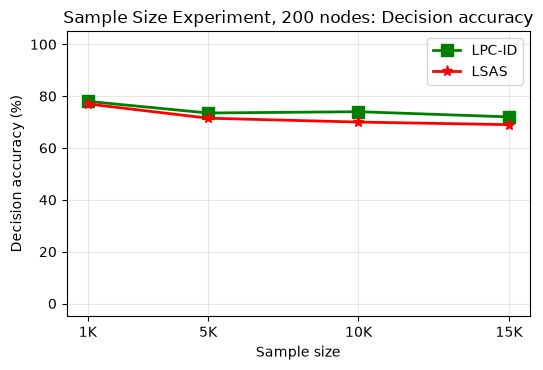

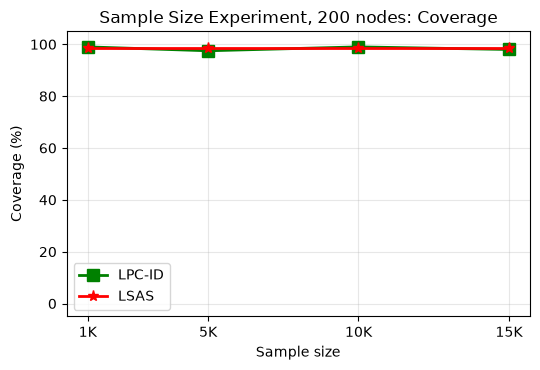

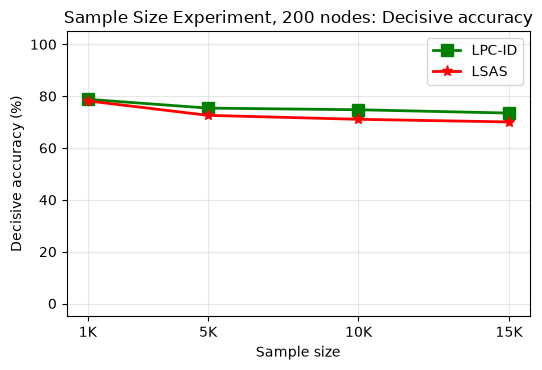

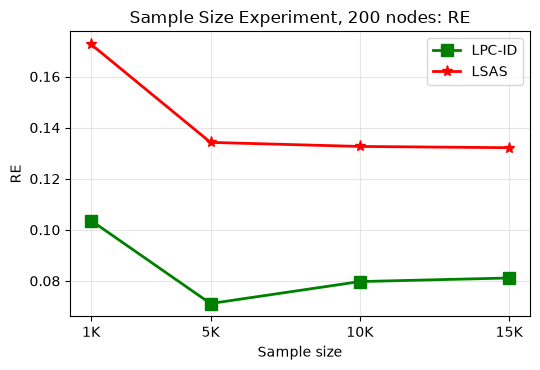

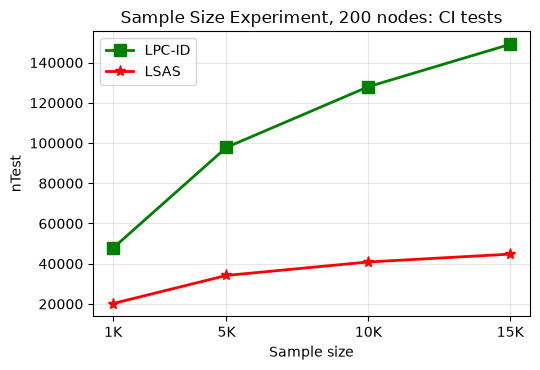

In [29]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


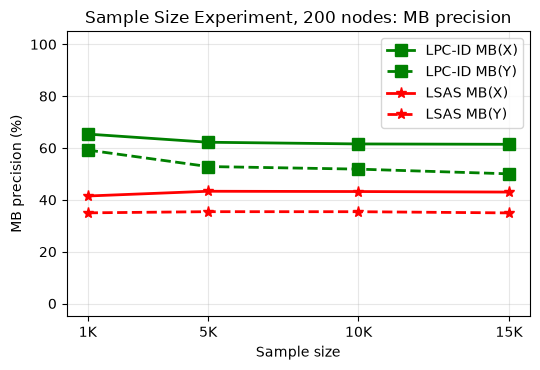

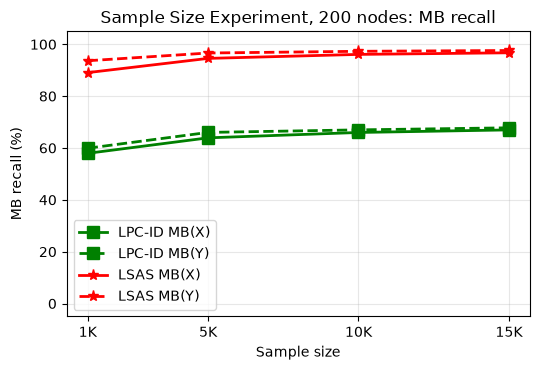

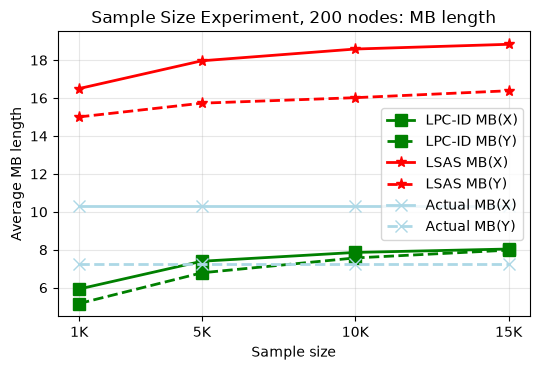

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,200,5.930,2.789986,10.310,11.088674,0.653654,0.256026,0.579473,0.317888
1,1000,LPC-ID,Y,200,5.165,2.693333,7.275,9.300639,0.592100,0.287867,0.599073,0.329345
2,1000,LSAS,X,200,16.500,6.233319,10.310,11.088674,0.414783,0.192606,0.890727,0.206400
3,1000,LSAS,Y,200,15.005,5.389826,7.275,9.300639,0.349811,0.185407,0.936493,0.168877
4,5000,LPC-ID,X,200,7.395,3.580934,10.310,11.088674,0.622185,0.248876,0.639148,0.297435
5,5000,LPC-ID,Y,200,6.785,3.527177,7.275,9.300639,0.528450,0.266645,0.660073,0.308199
6,5000,LSAS,X,200,17.965,7.668625,10.310,11.088674,0.433100,0.220827,0.945614,0.131210
7,5000,LSAS,Y,200,15.730,6.604940,7.275,9.300639,0.354361,0.188154,0.966381,0.118276
8,10000,LPC-ID,X,200,7.860,3.741711,10.310,11.088674,0.615627,0.250157,0.659835,0.290610
9,10000,LPC-ID,Y,200,7.570,4.215919,7.275,9.300639,0.518450,0.282806,0.669939,0.303679


In [30]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)
sample_size_base_mb_comparison


### 250 nodes


In [40]:
BASE_N_OBS = 250
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [41]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results


Running Sample Size Experiment, n_obs = 250... with sample size 1000 for 200 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 200/200 [15:07<00:00,  4.54s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 5000 for 200 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 200/200 [20:43<00:00,  6.22s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 10000 for 200 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 200/200 [23:41<00:00,  7.11s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 15000 for 200 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 200/200 [26:10<00:00,  7.85s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,0,+,+,True,True,2.045202,1.981520,...,"[V24, V38]","[V11, V15, V217, V24, V74, outcome]","[V15, V24, treatment]",4,3,3.5,0.011952,0,1.0,250
1,LSAS,"Sample Size Experiment, n_obs = 250...",1000,0,+,+,True,True,2.045202,2.003255,...,"[V4, V15, V22, V24, V29, V91, V92, V111, V145,...","[V11, V15, V217, V24, V74, outcome]","[V15, V24, treatment]",4,3,3.5,0.011952,0,1.0,250
2,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,1,0,+,False,True,0.000000,0.411189,...,"[V125, V157, V223, V40, V79, V91]","[V133, V229]","[V10, V223, V79, V91]",2,4,3.0,0.011952,0,1.0,250
3,LSAS,"Sample Size Experiment, n_obs = 250...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V10, V14, V64, V79, V84, V91, V115, V157, V19...","[V133, V229]","[V10, V223, V79, V91]",2,4,3.0,0.011952,0,1.0,250
4,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,2,+,+,True,True,1.301543,1.324387,...,"[V115, V195, V248, V47]","[V117, V122, V195, V29, V35, V47, V70, outcome]","[V195, V47, treatment]",6,3,4.5,0.011952,0,1.0,250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Sample Size Experiment, n_obs = 250...",15000,197,0,+,False,True,0.000000,0.399076,...,"[V26, V28, V33, V35, V46, V48, V65, V71, V76, ...","[V18, V187, V204, V80]","[V133, V35, V71, V83]",4,4,4.0,0.011952,0,1.0,250
1596,LPC-ID,"Sample Size Experiment, n_obs = 250...",15000,198,+,+,True,True,2.821145,2.791782,...,"[V138, V17, V186, V187, V194]","[V134, V138, V208, V219, V224, V230, V233, V47...","[V138, V233, treatment]",7,3,5.0,0.011952,0,1.0,250
1597,LSAS,"Sample Size Experiment, n_obs = 250...",15000,198,+,+,True,True,2.821145,2.818427,...,"[V27, V91, V98, V108, V138, V167, V177, V178, ...","[V134, V138, V208, V219, V224, V230, V233, V47...","[V138, V233, treatment]",7,3,5.0,0.011952,0,1.0,250
1598,LPC-ID,"Sample Size Experiment, n_obs = 250...",15000,199,0,+,False,True,0.000000,0.183997,...,"[V187, V65, V88]","[V109, V118, V165, V52, V96]","[V65, V88]",5,2,3.5,0.011952,0,1.0,250


In [42]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.845,1.000,200,0.845000,200
1,LPC-ID,5000,0.845,0.995,200,0.849246,199
2,LPC-ID,10000,0.835,0.990,200,0.843434,198
3,LPC-ID,15000,0.815,0.995,200,0.819095,199
4,LSAS,1000,0.805,0.985,200,0.817259,197
5,LSAS,5000,0.795,0.985,200,0.807107,197
6,LSAS,10000,0.830,0.995,200,0.834171,199
7,LSAS,15000,0.790,0.985,200,0.802030,197


In [43]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.076351,0.181791,42233.465,24097.957556
1,LPC-ID,5000,0.060871,0.174705,72955.630,55379.521591
2,LPC-ID,10000,0.064067,0.192347,90144.125,79072.013658
3,LPC-ID,15000,0.056634,0.179022,102052.560,90219.918119
4,LSAS,1000,0.111783,0.198832,19509.510,21824.423812
5,LSAS,5000,0.097683,0.195120,18225.655,17418.286348
6,LSAS,10000,0.100263,0.215707,17876.735,17470.744269
7,LSAS,15000,0.076734,0.166494,16500.255,15102.209900


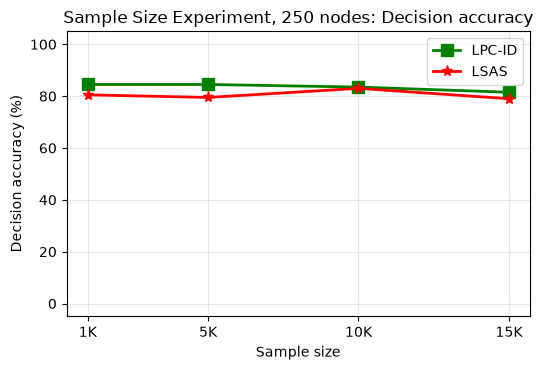

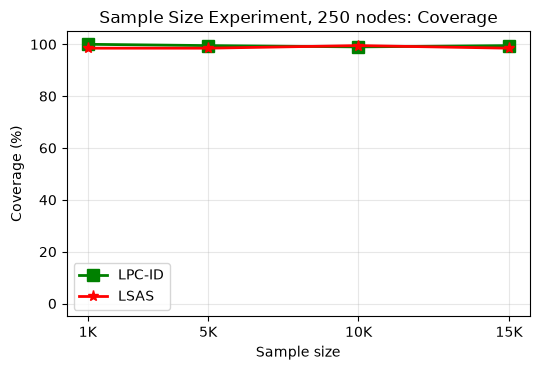

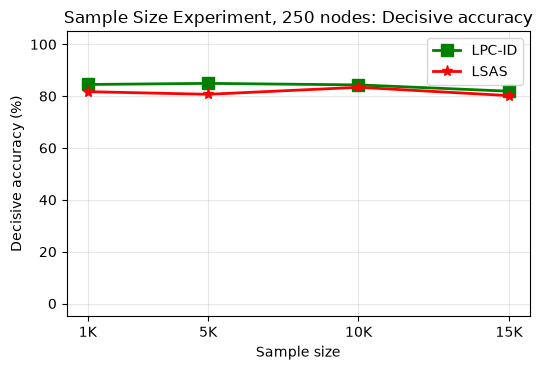

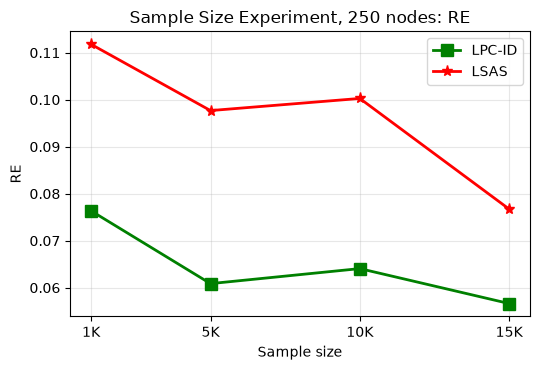

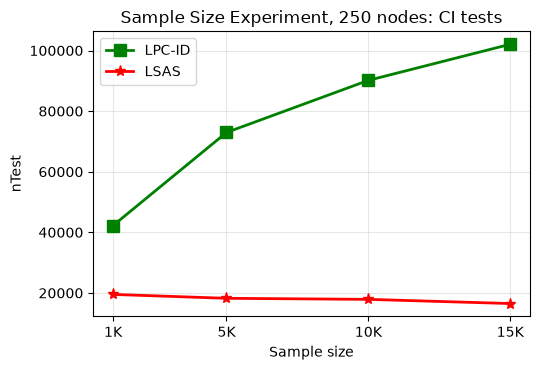

In [44]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


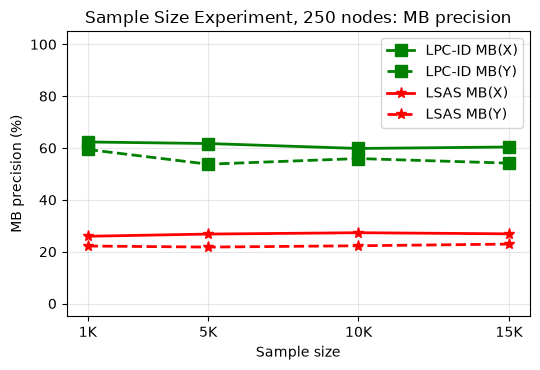

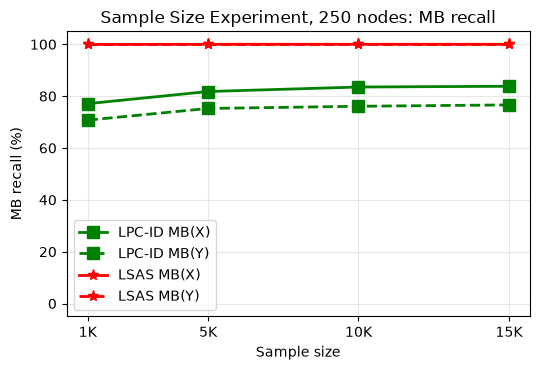

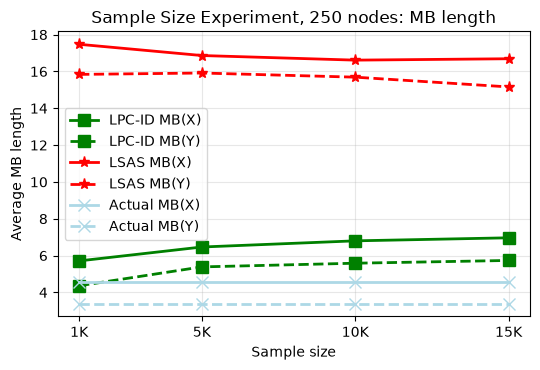

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,200,5.710,2.777494,4.565,2.813423,0.623237,0.280793,0.770966,0.224934
1,1000,LPC-ID,Y,200,4.360,2.318898,3.395,1.715720,0.594230,0.281970,0.707461,0.272670
2,1000,LSAS,X,200,17.475,5.482670,4.565,2.813423,0.259454,0.145254,0.999482,0.007198
3,1000,LSAS,Y,200,15.840,4.866499,3.395,1.715720,0.221887,0.111853,1.000000,0.000000
4,5000,LPC-ID,X,200,6.465,3.461021,4.565,2.813423,0.617221,0.287350,0.817845,0.191490
5,5000,LPC-ID,Y,200,5.385,3.149025,3.395,1.715720,0.537574,0.258676,0.752496,0.265006
6,5000,LSAS,X,200,16.865,4.862612,4.565,2.813423,0.267977,0.146021,1.000000,0.000000
7,5000,LSAS,Y,200,15.915,4.083030,3.395,1.715720,0.217744,0.108452,1.000000,0.000000
8,10000,LPC-ID,X,200,6.800,3.602065,4.565,2.813423,0.598163,0.277762,0.835207,0.176598
9,10000,LPC-ID,Y,200,5.585,3.554709,3.395,1.715720,0.559211,0.287291,0.760962,0.258531


In [45]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_base_mb_comparison


### 400 nodes


In [46]:
BASE_N_OBS = 400
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [47]:
sample_size_alt_nobs_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
)

sample_size_alt_nobs_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_alt_nobs_results


Running Sample Size Experiment, n_obs = 400... with sample size 1000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [45:14<00:00, 13.57s/it]


Running Sample Size Experiment, n_obs = 400... with sample size 5000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [56:27<00:00, 16.94s/it] 


Running Sample Size Experiment, n_obs = 400... with sample size 10000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [1:00:33<00:00, 18.17s/it]


Running Sample Size Experiment, n_obs = 400... with sample size 15000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [1:06:08<00:00, 19.84s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,1.212261,1.175721,...,"[V104, V122, V16, V92]","[V104, V122, V154, V16, V278, V280, outcome]","[V104, V122, V16, treatment]",4,4,4.0,0.007481,0,1.0,400
1,LSAS,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,1.212261,1.222284,...,"[V12, V16, V17, V55, V59, V76, V104, V108, V12...","[V104, V122, V154, V16, V278, V280, outcome]","[V104, V122, V16, treatment]",4,4,4.0,0.007481,0,1.0,400
2,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V127, V61]",[],[V127],0,1,0.5,0.007481,0,1.0,400
3,LSAS,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V36, V45, V51, V84, V85, V86, V127, V138, V17...",[],[V127],0,1,0.5,0.007481,0,1.0,400
4,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,2,+,+,True,True,1.998528,2.027839,...,"[V268, V336, V366]","[V180, V25, V268, V307, V336, V366, V379, outc...","[V336, V366, treatment]",6,3,4.5,0.007481,0,1.0,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Sample Size Experiment, n_obs = 400...",15000,197,0,0,True,True,0.000000,0.000000,...,"[V3, V42, V95, V165, V170, V203, V219, V221, V...","[V132, V182, V295, V373]","[V224, V264, V328]",4,3,3.5,0.007481,0,1.0,400
1596,LPC-ID,"Sample Size Experiment, n_obs = 400...",15000,198,+,+,True,True,2.622127,2.654984,...,"[V115, V142, V160, V165, V326, V335, V353]","[V115, V142, V326, V335, outcome]","[V115, V142, V326, V335, treatment]",1,5,3.0,0.007481,0,1.0,400
1597,LSAS,"Sample Size Experiment, n_obs = 400...",15000,198,+,0,False,True,2.622127,0.000000,...,"[V28, V53, V62, V64, V97, V102, V115, V142, V1...","[V115, V142, V326, V335, outcome]","[V115, V142, V326, V335, treatment]",1,5,3.0,0.007481,0,1.0,400
1598,LPC-ID,"Sample Size Experiment, n_obs = 400...",15000,199,0,0,True,True,0.000000,0.000000,...,"[V125, V263, V3]","[V158, V193]","[V125, V263, V3]",2,3,2.5,0.007481,0,1.0,400


In [48]:
sample_size_alt_nobs_decision_metrics = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_alt_nobs_decisive_metrics = (
    sample_size_alt_nobs_results[sample_size_alt_nobs_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_alt_nobs_decision_metrics = sample_size_alt_nobs_decision_metrics.merge(
    sample_size_alt_nobs_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_alt_nobs_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.855,1.000,200,0.855000,200
1,LPC-ID,5000,0.800,0.990,200,0.808081,198
2,LPC-ID,10000,0.835,1.000,200,0.835000,200
3,LPC-ID,15000,0.845,0.995,200,0.849246,199
4,LSAS,1000,0.825,0.980,200,0.841837,196
5,LSAS,5000,0.770,0.985,200,0.781726,197
6,LSAS,10000,0.825,0.985,200,0.837563,197
7,LSAS,15000,0.790,0.985,200,0.802030,197


In [49]:
sample_size_alt_nobs_effect_effort = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_alt_nobs_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.079591,0.203467,81883.225,38315.388455
1,LPC-ID,5000,0.065978,0.190275,134514.800,81986.538191
2,LPC-ID,10000,0.050965,0.164912,160111.670,111702.696925
3,LPC-ID,15000,0.041066,0.142402,181728.430,140465.731761
4,LSAS,1000,0.083797,0.125411,77861.890,102937.313746
5,LSAS,5000,0.072897,0.152989,81050.160,73533.864449
6,LSAS,10000,0.074587,0.150209,73612.130,63612.949140
7,LSAS,15000,0.075357,0.168380,77008.165,67288.354709


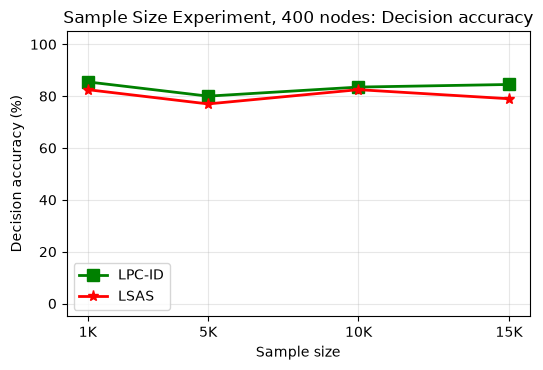

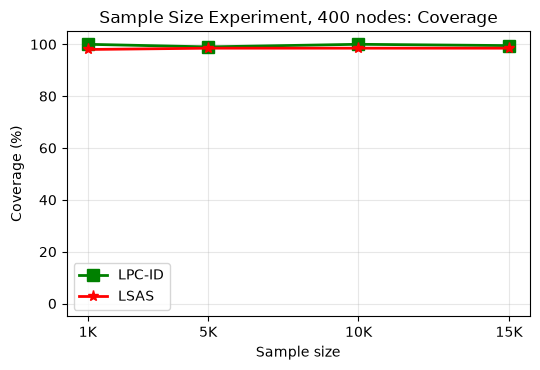

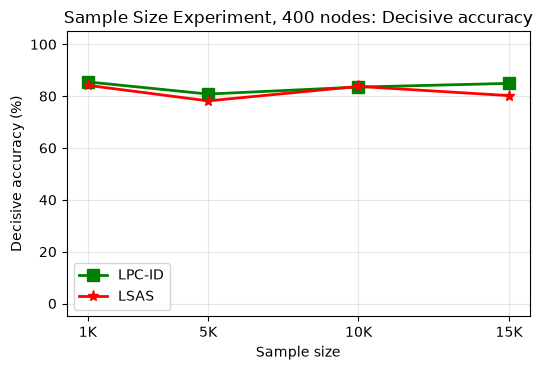

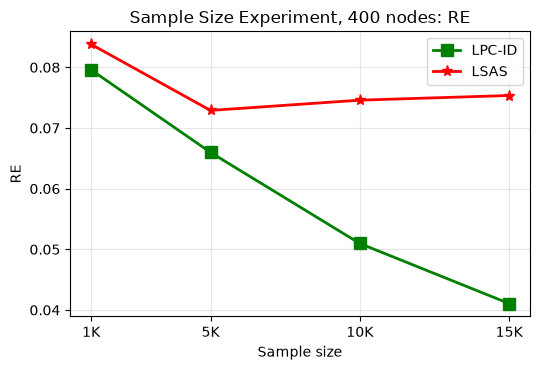

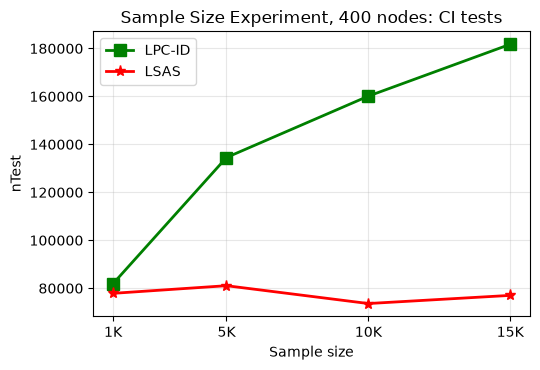

In [50]:
plot_experiment_metrics(
    decision_df=sample_size_alt_nobs_decision_metrics,
    effect_df=sample_size_alt_nobs_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


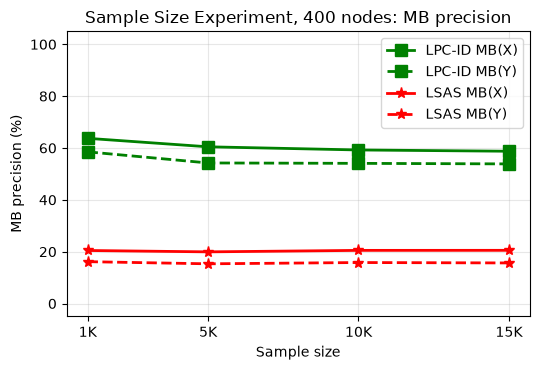

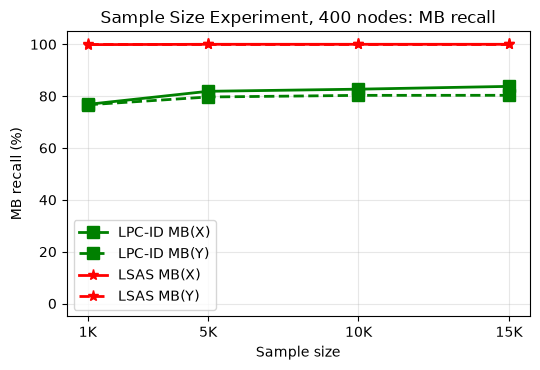

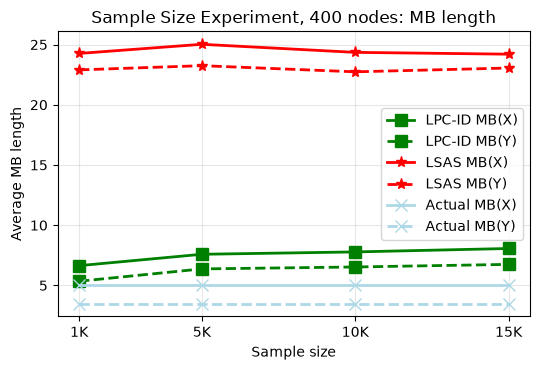

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,200,6.640,3.982424,5.020,2.884650,0.637289,0.291623,0.768251,0.214661
1,1000,LPC-ID,Y,200,5.345,3.369383,3.495,1.747928,0.585131,0.276855,0.766625,0.244091
2,1000,LSAS,X,200,24.260,6.654609,5.020,2.884650,0.204620,0.109248,0.998698,0.018042
3,1000,LSAS,Y,200,22.895,6.560425,3.495,1.747928,0.161468,0.091349,1.000000,0.000000
4,5000,LPC-ID,X,200,7.585,4.532715,5.020,2.884650,0.604580,0.283810,0.818699,0.186360
5,5000,LPC-ID,Y,200,6.370,4.349447,3.495,1.747928,0.542275,0.271454,0.796713,0.220152
6,5000,LSAS,X,200,25.020,6.293460,5.020,2.884650,0.199333,0.105021,1.000000,0.000000
7,5000,LSAS,Y,200,23.245,5.484100,3.495,1.747928,0.153237,0.075975,1.000000,0.000000
8,10000,LPC-ID,X,200,7.780,4.307479,5.020,2.884650,0.592388,0.278328,0.826863,0.180031
9,10000,LPC-ID,Y,200,6.530,4.474282,3.495,1.747928,0.540728,0.270387,0.803017,0.217262


In [51]:
sample_size_alt_nobs_mb_comparison, sample_size_alt_nobs_mb_comparison_detail = compare_markov_blankets(
    sample_size_alt_nobs_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_alt_nobs_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_alt_nobs_mb_comparison


## Graph Size Experiment


In [52]:
graph_size_results_list = []

for graph_size in graph_sizes:
    results_one_graph_size = run_structure_experiment(
        structure_name=f"Graph size experiment, n_obs={graph_size}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=graph_size,
        p=p_for_size(graph_size, TARGET_AVG_DEGREE),
        beta=BASE_BETA,
        n_latent = int(0.1 * graph_size),
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_graph_size["graph_size"] = graph_size
    graph_size_results_list.append(results_one_graph_size)

graph_size_results = pd.concat(graph_size_results_list, ignore_index=True)
graph_size_results


Running Graph size experiment, n_obs=100 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=100: 100%|██████████| 200/200 [09:20<00:00,  2.80s/it]


Running Graph size experiment, n_obs=200 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=200: 100%|██████████| 200/200 [24:59<00:00,  7.50s/it]


Running Graph size experiment, n_obs=300 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=300: 100%|██████████| 200/200 [49:58<00:00, 14.99s/it] 


Running Graph size experiment, n_obs=400 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=400: 100%|██████████| 200/200 [1:32:41<00:00, 27.81s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,graph_size
0,LPC-ID,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,2.759387,3.164021,...,"[V12, V24, V63, V79, V89]","[V12, V19, V24, V29, V37, V38, V44, V6, V63, V...","[V19, V29, V37, V38, V44, V6, V75, V85, V89, V...",6,5,5.5,0.029703,0,1.0,100
1,LSAS,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,2.759387,3.068734,...,"[V6, V19, V29, V37, V38, V44, V75, V85, V89, V...","[V12, V19, V24, V29, V37, V38, V44, V6, V63, V...","[V19, V29, V37, V38, V44, V6, V75, V85, V89, V...",6,5,5.5,0.029703,0,1.0,100
2,LPC-ID,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V5, V60, V72, V86, V97]","[V36, V7]","[V5, V60, V72, V97]",2,4,3.0,0.029703,0,1.0,100
3,LSAS,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V5, V31, V60, V72, V97]","[V36, V7]","[V5, V60, V72, V97]",2,4,3.0,0.029703,0,1.0,100
4,LPC-ID,"Graph size experiment, n_obs=100",5000,2,+,+,True,True,1.270962,1.541188,...,"[V16, V28, V44, V64, V98]","[V15, V25, V27, V28, V29, V33, V35, V37, V45, ...","[V27, V28, V5, V56, V77, treatment]",6,6,6.0,0.029703,0,1.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Graph size experiment, n_obs=400",5000,197,0,+,False,True,0.000000,-0.039262,...,"[V25, V42, V67, V72, V79, V92, V141, V157, V15...","[V129, V165, V255, V289, V57]","[V363, V390]",5,2,3.5,0.007481,0,1.0,400
1596,LPC-ID,"Graph size experiment, n_obs=400",5000,198,+,+,True,True,2.791407,2.773990,...,"[V23, V328, V331]","[V23, V298, V312, V328, V99, outcome]","[V23, V328, treatment]",5,3,4.0,0.007481,0,1.0,400
1597,LSAS,"Graph size experiment, n_obs=400",5000,198,+,+,True,True,2.791407,2.767430,...,"[V23, V30, V38, V39, V42, V50, V60, V84, V97, ...","[V23, V298, V312, V328, V99, outcome]","[V23, V328, treatment]",5,3,4.0,0.007481,0,1.0,400
1598,LPC-ID,"Graph size experiment, n_obs=400",5000,199,0,0,True,True,0.000000,0.000000,...,"[V219, V248, V25, V381, V72]","[V272, V283, V288, V299, V325, V340, V349, V36...","[V25, V381]",8,2,5.0,0.007481,0,1.0,400


In [53]:
graph_size_decision_metrics = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

graph_size_decisive_metrics = (
    graph_size_results[graph_size_results["is_decisive"]]
    .groupby(["graph_size", "method"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

graph_size_decision_metrics = graph_size_decision_metrics.merge(
    graph_size_decisive_metrics,
    on=["graph_size", "method"],
    how="left",
)

graph_size_decision_metrics["n_decisive"] = graph_size_decision_metrics["n_decisive"].fillna(0).astype(int)

graph_size_decision_metrics


,method,graph_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,100,0.695,0.975,200,0.712821,195
1,LPC-ID,200,0.690,0.985,200,0.700508,197
2,LPC-ID,300,0.790,1.000,200,0.790000,200
3,LPC-ID,400,0.765,0.995,200,0.768844,199
4,LSAS,100,0.670,0.995,200,0.673367,199
5,LSAS,200,0.670,0.970,200,0.690722,194
6,LSAS,300,0.725,0.990,200,0.732323,198
7,LSAS,400,0.710,1.000,200,0.710000,200


In [54]:
graph_size_effect_effort = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

graph_size_effect_effort


,method,graph_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,100,0.113437,0.211289,40575.370,23055.060373
1,LPC-ID,200,0.073334,0.163892,93847.690,58174.395478
2,LPC-ID,300,0.050373,0.140078,149908.565,99460.851037
3,LPC-ID,400,0.058021,0.148470,218904.055,160176.837957
4,LSAS,100,0.173650,0.277057,7972.745,19707.025249
5,LSAS,200,0.116968,0.203108,28424.300,54951.928196
6,LSAS,300,0.091514,0.140542,74424.530,193907.924900
7,LSAS,400,0.111373,0.212859,155384.685,226233.257085


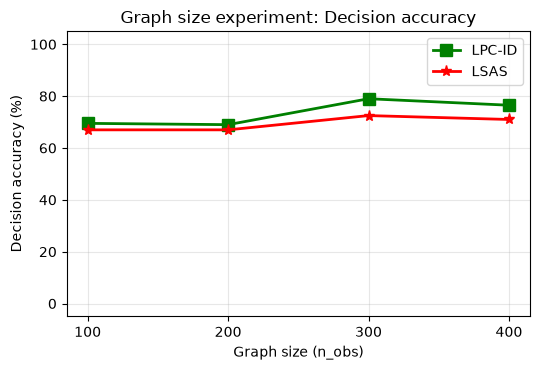

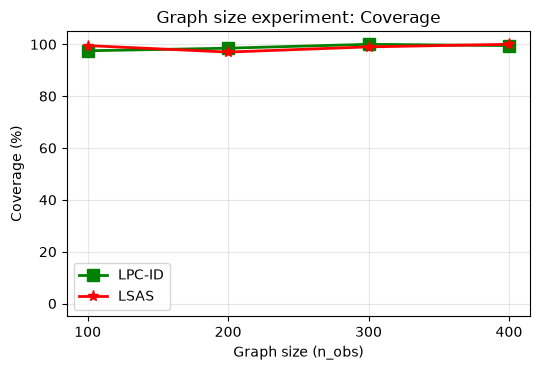

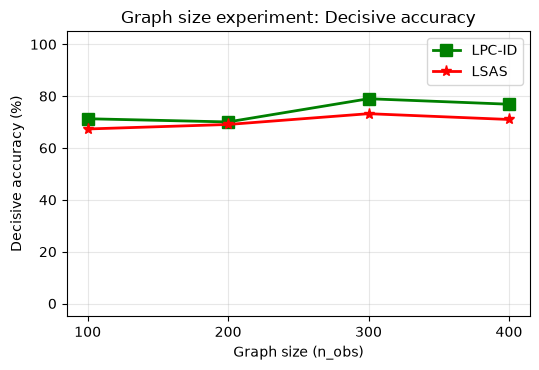

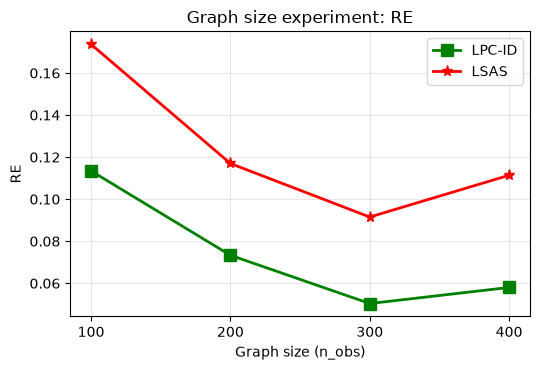

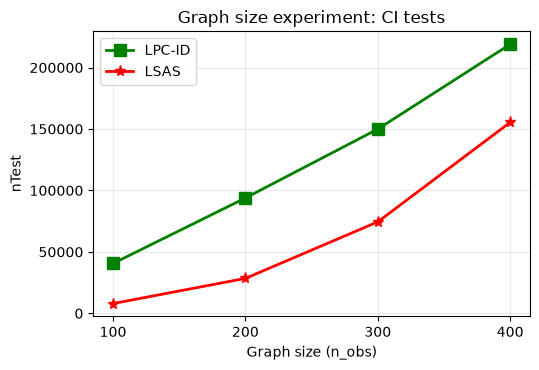

In [55]:
plot_experiment_metrics(
    decision_df=graph_size_decision_metrics,
    effect_df=graph_size_effect_effort,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)


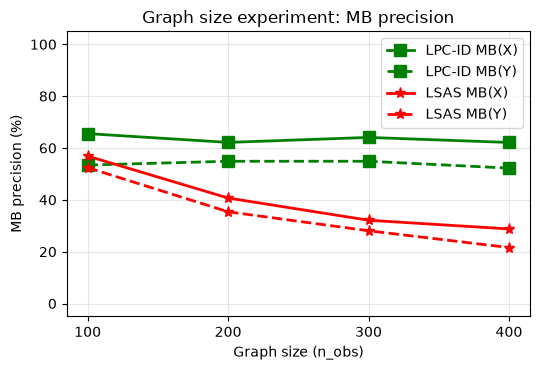

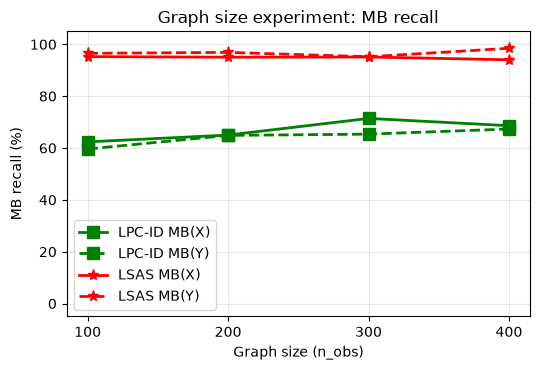

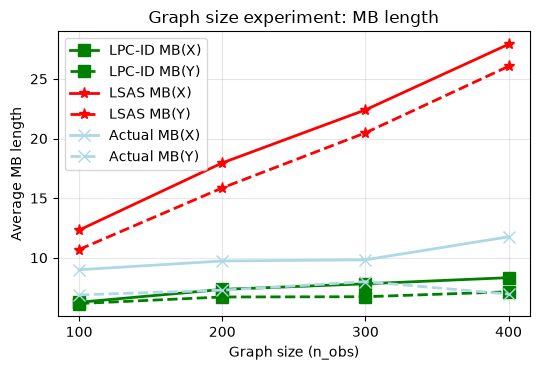

,graph_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,100,LPC-ID,X,200,6.270,2.917130,9.000,8.702221,0.655438,0.261803,0.623563,0.289736
1,100,LPC-ID,Y,200,6.165,3.149184,6.890,7.402152,0.534191,0.264016,0.596121,0.311439
2,100,LSAS,X,200,12.320,5.705292,9.000,8.702221,0.568751,0.234760,0.952492,0.133358
3,100,LSAS,Y,200,10.695,4.841402,6.890,7.402152,0.524115,0.222621,0.965154,0.120004
4,200,LPC-ID,X,200,7.350,3.310938,9.730,11.314912,0.621556,0.267593,0.649828,0.277634
5,200,LPC-ID,Y,200,6.715,3.857223,7.285,9.228739,0.548790,0.273029,0.648565,0.301408
6,200,LSAS,X,200,17.955,6.779586,9.730,11.314912,0.407015,0.208726,0.950130,0.133213
7,200,LSAS,Y,200,15.860,6.259899,7.285,9.228739,0.353967,0.188972,0.968834,0.113916
8,300,LPC-ID,X,200,7.820,4.058319,9.830,11.284405,0.640764,0.264260,0.714058,0.285012
9,300,LPC-ID,Y,200,6.735,3.994314,8.000,11.283465,0.548862,0.258059,0.653492,0.304440


In [56]:
graph_size_mb_comparison, graph_size_mb_comparison_detail = compare_markov_blankets(
    graph_size_results,
    group_cols=["graph_size"],
)

plot_markov_blanket_metrics(
    graph_size_mb_comparison,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)

graph_size_mb_comparison


## Average Degree Experiment


### 100 Nodes

In [57]:
BASE_N_OBS = 100
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [58]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE,
        n_latent = BASE_N_LATENT
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=2 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=2: 100%|██████████| 200/200 [02:52<00:00,  1.16it/s]


Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [09:25<00:00,  2.83s/it]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [25:47<00:00,  7.74s/it] 


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [34:24<00:00, 10.32s/it]  


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.482895,1.470616,...,"[V1, V97]","[V1, V21, V91, V97, outcome]","[V97, treatment]",4,2,3.0,0.019802,0,1.0,2
1,LSAS,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.482895,1.466510,...,"[V8, V37, V97, treatment]","[V1, V21, V91, V97, outcome]","[V97, treatment]",4,2,3.0,0.019802,0,1.0,2
2,LPC-ID,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V20, V62, V78, V79]","[V22, V92]",[V78],2,1,1.5,0.019802,0,1.0,2
3,LSAS,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V27, V36, V71, V75, V78]","[V22, V92]",[V78],2,1,1.5,0.019802,0,1.0,2
4,LPC-ID,"Average degree experiment, avg_degree=2",5000,2,+,+,True,True,1.425673,1.475505,...,"[V57, V78]","[V15, V23, V31, V4, V57, V65, V78, V90, outcome]","[V31, V57, V78, treatment]",6,4,5.0,0.019802,0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=5",5000,197,0,+,False,True,0.000000,0.005377,...,"[V65, V71, V94]","[V0, V25, V41, V72]",[],4,0,2.0,0.049505,0,1.0,5
1596,LPC-ID,"Average degree experiment, avg_degree=5",5000,198,+,0,False,True,2.561311,0.000000,...,"[V10, V32, V4, V56, V69]","[V0, V1, V10, V13, V16, V2, V23, V26, V27, V29...","[V1, V13, V16, V26, V31, V44, V6, V60, V62, V6...",8,7,7.5,0.049505,0,1.0,5
1597,LSAS,"Average degree experiment, avg_degree=5",5000,198,+,+,True,True,2.561311,2.792954,...,"[V1, V6, V13, V16, V26, V28, V31, V42, V44, V6...","[V0, V1, V10, V13, V16, V2, V23, V26, V27, V29...","[V1, V13, V16, V26, V31, V44, V6, V60, V62, V6...",8,7,7.5,0.049505,0,1.0,5
1598,LPC-ID,"Average degree experiment, avg_degree=5",5000,199,0,+,False,True,0.000000,0.863909,...,"[V33, V6, V63, V77, V78]","[V14, V23, V28, V42, V47, V5, V66, V75, V82, V95]","[V45, V55, V63, V69, V93]",3,5,4.0,0.049505,0,1.0,5


In [59]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,2,0.930,0.965,200,0.963731,193
1,LPC-ID,3,0.695,0.975,200,0.712821,195
2,LPC-ID,4,0.580,0.990,200,0.585859,198
3,LPC-ID,5,0.485,0.965,200,0.502591,193
4,LSAS,2,0.895,0.955,200,0.937173,191
5,LSAS,3,0.670,0.995,200,0.673367,199
6,LSAS,4,0.580,1.000,200,0.580000,200
7,LSAS,5,0.510,1.000,200,0.510000,200


In [60]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,2,0.038921,0.145001,9493.875,6155.468301
1,LPC-ID,3,0.113437,0.211289,40575.370,23055.060373
2,LPC-ID,4,0.206566,0.353167,85512.185,36858.341570
3,LPC-ID,5,0.385742,0.463293,95004.990,35627.668405
4,LSAS,2,0.039228,0.114785,1852.715,3961.417171
5,LSAS,3,0.173650,0.277057,7972.745,19707.025249
6,LSAS,4,0.535639,0.922369,52533.050,198205.839433
7,LSAS,5,0.952580,1.391804,84793.000,264039.741761


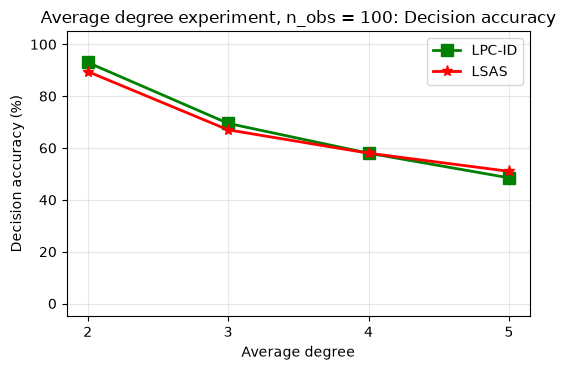

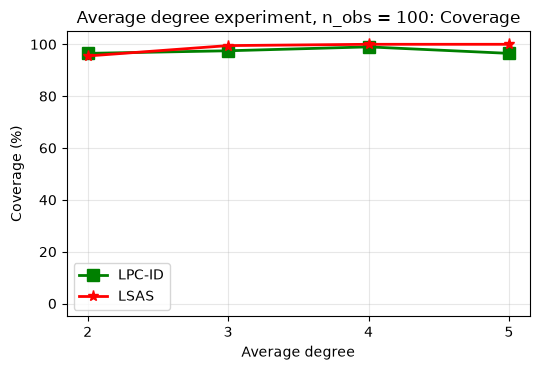

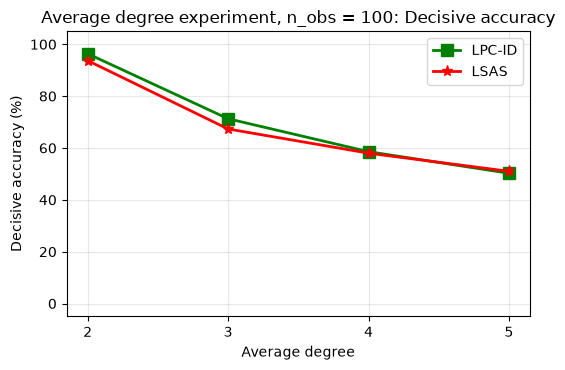

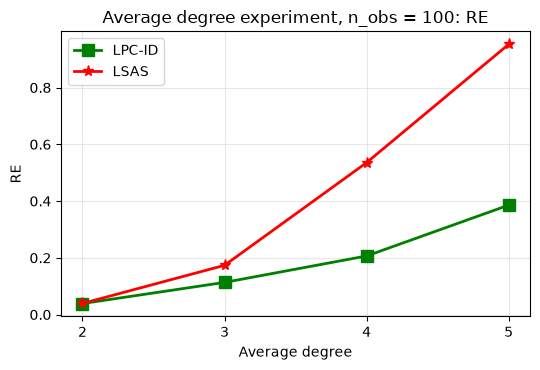

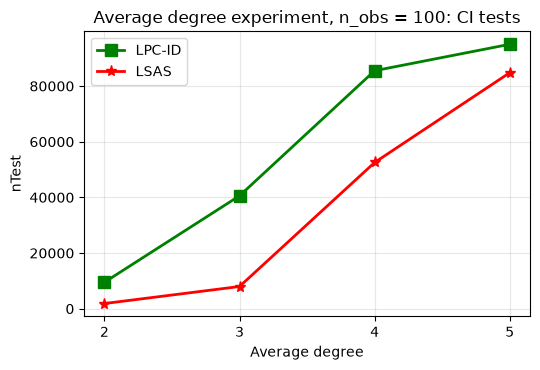

In [61]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


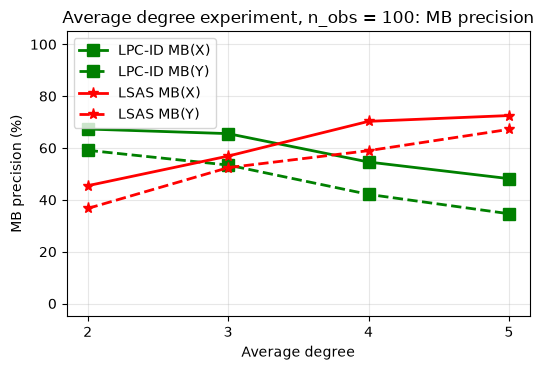

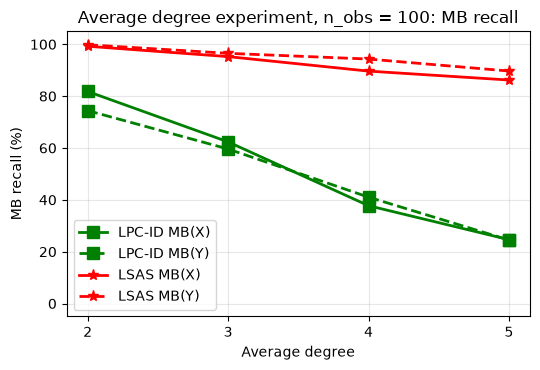

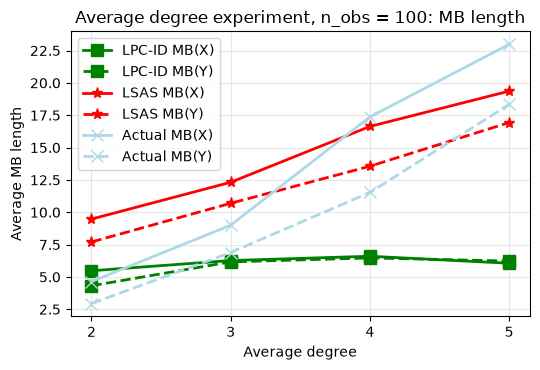

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,2,LPC-ID,X,200,5.480,2.502180,4.645,3.715914,0.673114,0.305947,0.818099,0.206638
1,2,LPC-ID,Y,200,4.320,2.766926,2.945,2.560224,0.591150,0.338249,0.744240,0.269995
2,2,LSAS,X,200,9.475,3.831813,4.645,3.715914,0.454499,0.222090,0.992480,0.052929
3,2,LSAS,Y,200,7.705,3.415598,2.945,2.560224,0.366732,0.206818,0.998233,0.012273
4,3,LPC-ID,X,200,6.270,2.917130,9.000,8.702221,0.655438,0.261803,0.623563,0.289736
5,3,LPC-ID,Y,200,6.165,3.149184,6.890,7.402152,0.534191,0.264016,0.596121,0.311439
6,3,LSAS,X,200,12.320,5.705292,9.000,8.702221,0.568751,0.234760,0.952492,0.133358
7,3,LSAS,Y,200,10.695,4.841402,6.890,7.402152,0.524115,0.222621,0.965154,0.120004
8,4,LPC-ID,X,200,6.600,2.524254,17.370,16.935084,0.545881,0.262195,0.377482,0.295616
9,4,LPC-ID,Y,200,6.470,2.842446,11.530,14.376107,0.421086,0.267026,0.410396,0.307683


In [62]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 250 Nodes

In [63]:
BASE_N_OBS = 250
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [64]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE,
        n_latent = BASE_N_LATENT
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=2 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=2: 100%|██████████| 200/200 [16:53<00:00,  5.07s/it]


Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [35:50<00:00, 10.75s/it] 


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [1:45:07<00:00, 31.54s/it]  


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [2:29:35<00:00, 44.88s/it]  


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.157599,1.150711,...,"[V108, V11, V124, V13, V181, V196, V35, V59, V92]","[V120, V181, V6, V79, outcome]",[treatment],3,1,2.0,0.007968,0,1.0,2
1,LSAS,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.157599,1.167405,...,"[V18, V23, V59, V92, V94, V101, V106, V112, V1...","[V120, V181, V6, V79, outcome]",[treatment],3,1,2.0,0.007968,0,1.0,2
2,LPC-ID,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V114, V143, V182, V225, V230, V84]","[V116, V174]","[V114, V143, V182, V225]",2,2,2.0,0.007968,0,1.0,2
3,LSAS,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V2, V19, V44, V48, V56, V108, V114, V121, V14...","[V116, V174]","[V114, V143, V182, V225]",2,2,2.0,0.007968,0,1.0,2
4,LPC-ID,"Average degree experiment, avg_degree=2",5000,2,+,+,True,True,2.170377,2.358824,...,"[V108, V116, V125, V129, V16, V165, V197, V224...","[V1, V108, V116, V125, V129, V16, V165, V171, ...","[V1, V108, V116, V125, V129, V16, V165, V171, ...",4,3,3.5,0.007968,0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=5",5000,197,0,+,False,True,0.000000,1.625987,...,"[V3, V21, V27, V33, V36, V52, V59, V69, V71, V...","[V123, V137, V152, V189, V244, V58]","[V1, V10, V107, V108, V11, V112, V114, V115, V...",6,4,5.0,0.019920,0,1.0,5
1596,LPC-ID,"Average degree experiment, avg_degree=5",5000,198,+,+,True,True,2.787645,3.220229,...,"[V121, V182, V211, V236, V57]","[V101, V106, V108, V111, V118, V119, V12, V122...","[V123, V137, V164, V201, V207, V208, V221, V22...",12,6,9.0,0.019920,0,1.0,5
1597,LSAS,"Average degree experiment, avg_degree=5",5000,198,+,+,True,True,2.787645,4.022056,...,"[V0, V16, V30, V37, V38, V42, V48, V62, V73, V...","[V101, V106, V108, V111, V118, V119, V12, V122...","[V123, V137, V164, V201, V207, V208, V221, V22...",12,6,9.0,0.019920,0,1.0,5
1598,LPC-ID,"Average degree experiment, avg_degree=5",5000,199,0,+,False,True,0.000000,0.517928,...,"[V109, V193, V197, V202, V227, V93]","[V0, V1, V102, V103, V104, V106, V107, V109, V...","[V109, V19, V235, V60, V72]",7,5,6.0,0.019920,0,1.0,5


In [65]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,2,0.920,0.985,200,0.934010,197
1,LPC-ID,3,0.750,0.990,200,0.757576,198
2,LPC-ID,4,0.540,0.970,200,0.556701,194
3,LPC-ID,5,0.525,0.980,200,0.535714,196
4,LSAS,2,0.905,0.980,200,0.923469,196
5,LSAS,3,0.710,0.990,200,0.717172,198
6,LSAS,4,0.535,0.995,200,0.537688,199
7,LSAS,5,0.510,0.995,200,0.512563,199


In [66]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,2,0.075800,0.239532,49008.080,34274.934382
1,LPC-ID,3,0.065488,0.159118,125121.185,90445.864479
2,LPC-ID,4,0.142039,0.205444,358311.380,200330.553364
3,LPC-ID,5,0.225615,0.316924,414201.365,193273.118955
4,LSAS,2,0.067058,0.200609,19384.405,26240.446639
5,LSAS,3,0.115596,0.184453,43625.990,90677.574795
6,LSAS,4,0.428937,0.605254,151793.345,345577.241527
7,LSAS,5,0.706653,0.753954,301196.500,637282.007026


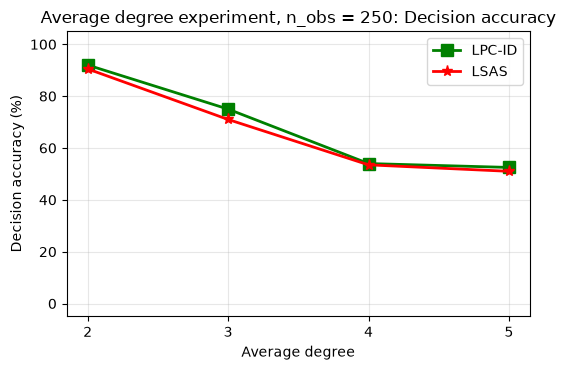

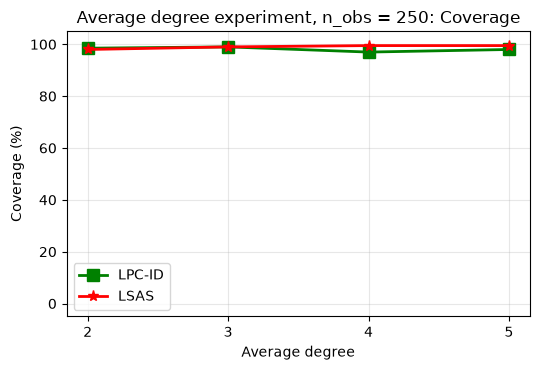

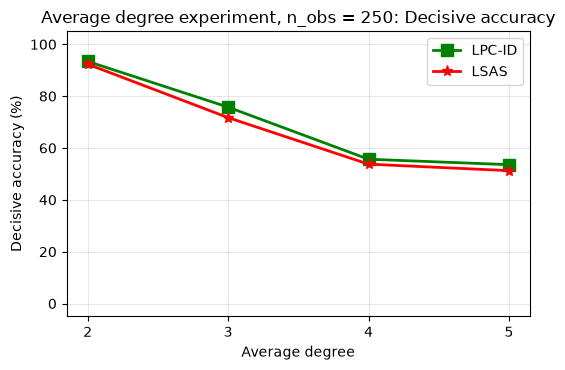

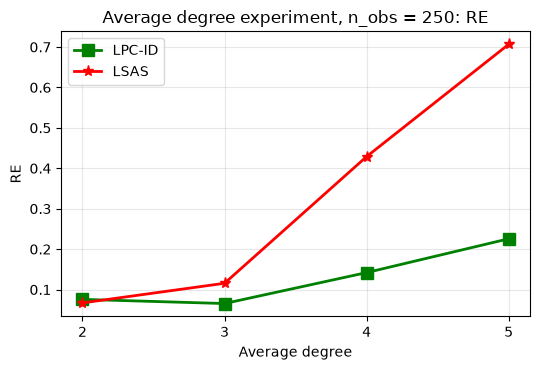

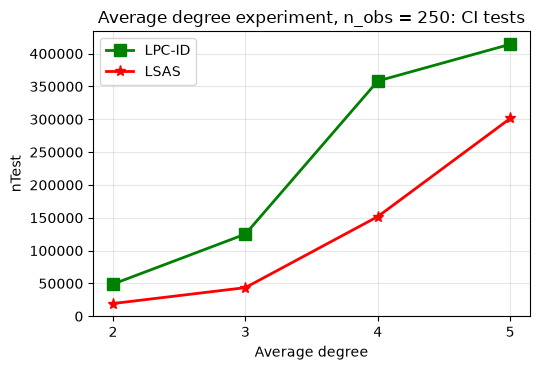

In [67]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


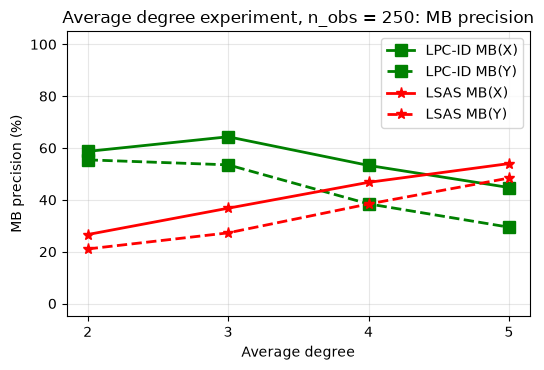

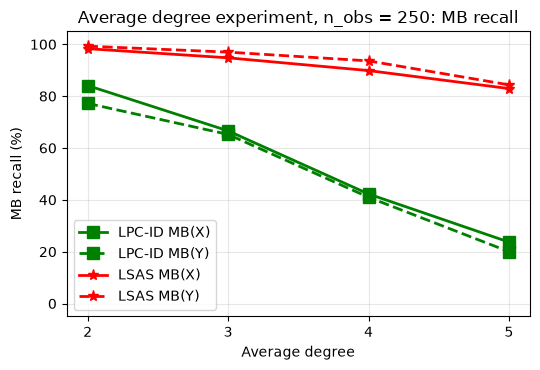

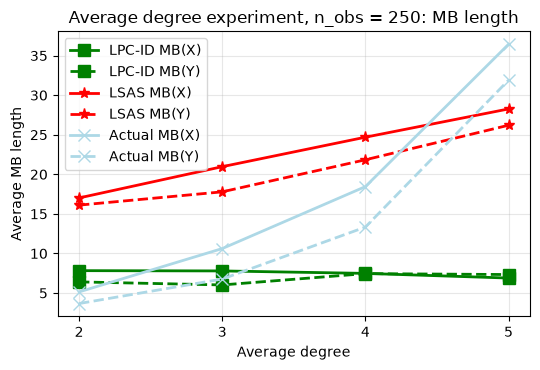

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,2,LPC-ID,X,200,7.825,4.436529,5.140,4.571091,0.586856,0.320482,0.840915,0.186148
1,2,LPC-ID,Y,200,6.405,5.023660,3.670,3.813636,0.554216,0.323859,0.771999,0.255297
2,2,LSAS,X,200,17.015,5.745418,5.140,4.571091,0.266096,0.161303,0.983149,0.087884
3,2,LSAS,Y,200,16.105,4.798867,3.670,3.813636,0.210515,0.139545,0.992770,0.041781
4,3,LPC-ID,X,200,7.790,4.007016,10.615,12.840607,0.643276,0.261044,0.666141,0.282271
5,3,LPC-ID,Y,200,6.020,3.697018,6.765,11.190887,0.535003,0.271413,0.652347,0.312356
6,3,LSAS,X,200,20.965,8.246441,10.615,12.840607,0.367685,0.190046,0.947816,0.146437
7,3,LSAS,Y,200,17.785,6.532391,6.765,11.190887,0.272582,0.162390,0.969806,0.124655
8,4,LPC-ID,X,200,7.480,3.362459,18.445,21.220474,0.532795,0.245447,0.422660,0.319079
9,4,LPC-ID,Y,200,7.450,3.730561,13.330,18.621085,0.384447,0.249351,0.410047,0.324585


In [68]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 400 Nodes

In [69]:
BASE_N_OBS = 400
BASE_N_LATENT = int(0.1 * BASE_N_OBS)

In [70]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE,
        n_latent = BASE_N_LATENT
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results


Running Average degree experiment, avg_degree=2 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=2: 100%|██████████| 200/200 [1:00:06<00:00, 18.03s/it]


Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [1:32:52<00:00, 27.86s/it]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [4:14:58<00:00, 76.49s/it]   


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [8:52:08<00:00, 159.64s/it]   


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.287476,1.268023,...,"[V190, V290, V338, V60]","[V247, V282, V290, V383, V385, V4, V60, outcome]","[V290, V60, treatment]",6,3,4.5,0.004988,0,1.0,2
1,LSAS,"Average degree experiment, avg_degree=2",5000,0,+,+,True,True,1.287476,1.263411,...,"[V2, V7, V16, V32, V33, V35, V60, V94, V95, V1...","[V247, V282, V290, V383, V385, V4, V60, outcome]","[V290, V60, treatment]",6,3,4.5,0.004988,0,1.0,2
2,LPC-ID,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V100, V13, V156, V162, V192, V221, V226, V229...","[V13, V136, V142, V152, V209, V249, V274, V303...",[V221],2,1,1.5,0.004988,0,1.0,2
3,LSAS,"Average degree experiment, avg_degree=2",5000,1,0,0,True,True,0.000000,0.000000,...,"[V17, V44, V49, V72, V76, V77, V83, V104, V156...","[V13, V136, V142, V152, V209, V249, V274, V303...",[V221],2,1,1.5,0.004988,0,1.0,2
4,LPC-ID,"Average degree experiment, avg_degree=2",5000,2,+,+,True,True,2.620761,2.619904,...,"[V383, V39, V48, V69, V75]","[V172, V190, V200, V315, V48, V69, V75, V93, o...","[V48, V69, V75, treatment]",6,4,5.0,0.004988,0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=5",5000,197,0,0,True,True,0.000000,0.000000,...,"[V1, V21, V33, V39, V42, V82, V88, V99, V125, ...","[V102, V108, V122, V128, V137, V141, V152, V16...","[V209, V216, V275, V33, V389, V42]",2,6,4.0,0.012469,0,1.0,5
1596,LPC-ID,"Average degree experiment, avg_degree=5",5000,198,+,+,True,True,2.012218,1.967600,...,"[V154, V161, V172, V18, V185, V199, V228, V274...","[V10, V147, V171, V194, V228, V311, V337, V36,...","[V10, V194, V228, V36, V370, V74, treatment]",6,7,6.5,0.012469,0,1.0,5
1597,LSAS,"Average degree experiment, avg_degree=5",5000,198,+,+,True,True,2.012218,2.373706,...,"[V10, V30, V32, V36, V39, V66, V74, V84, V89, ...","[V10, V147, V171, V194, V228, V311, V337, V36,...","[V10, V194, V228, V36, V370, V74, treatment]",6,7,6.5,0.012469,0,1.0,5
1598,LPC-ID,"Average degree experiment, avg_degree=5",5000,199,0,+,False,True,0.000000,0.431504,...,"[V10, V187, V244, V320, V339, V353, V41]","[V1, V10, V101, V103, V104, V109, V11, V110, V...","[V138, V192, V199, V292, V298, V41, V7]",10,7,8.5,0.012469,0,1.0,5


In [71]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,2,0.955,1.000,200,0.955000,200
1,LPC-ID,3,0.765,0.995,200,0.768844,199
2,LPC-ID,4,0.595,0.995,200,0.597990,199
3,LPC-ID,5,0.515,0.985,200,0.522843,197
4,LSAS,2,0.915,0.975,200,0.938462,195
5,LSAS,3,0.710,1.000,200,0.710000,200
6,LSAS,4,0.550,1.000,200,0.550000,200
7,LSAS,5,0.515,1.000,200,0.515000,200


In [72]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,2,0.042701,0.170890,157410.255,1.236358e+05
1,LPC-ID,3,0.058021,0.148470,218904.055,1.601768e+05
2,LPC-ID,4,0.104652,0.163083,754670.195,5.186208e+05
3,LPC-ID,5,0.199628,0.595487,1074679.805,5.429543e+05
4,LSAS,2,0.067955,0.201944,75305.720,8.057598e+04
5,LSAS,3,0.111373,0.212859,155384.685,2.262333e+05
6,LSAS,4,0.283749,0.393812,341725.535,8.244583e+05
7,LSAS,5,0.687943,0.797444,1006015.515,2.937858e+06


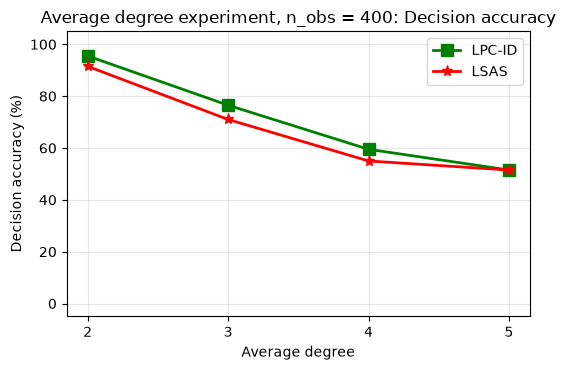

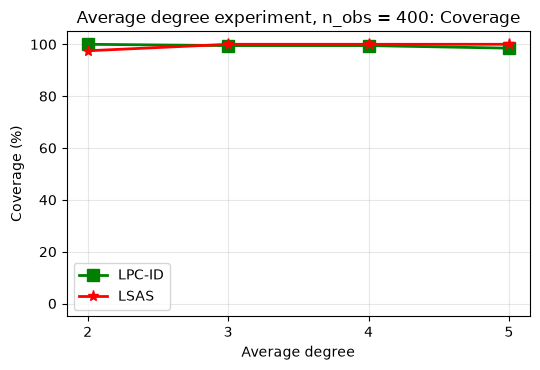

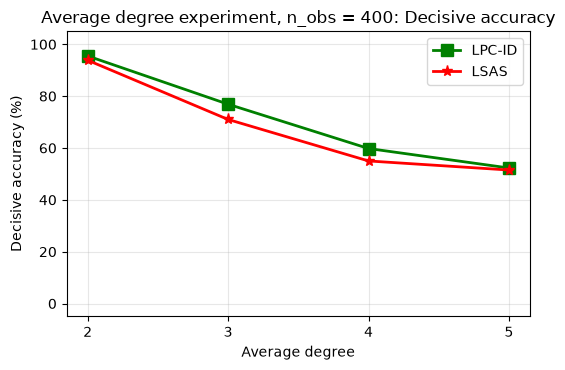

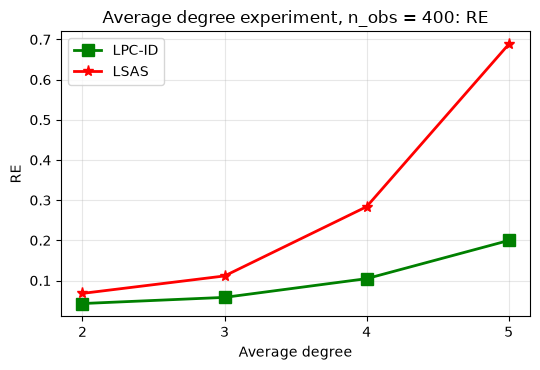

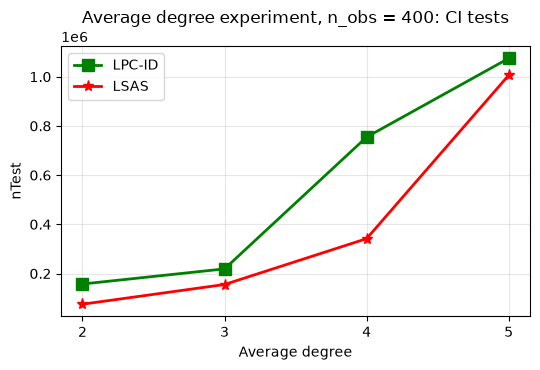

In [73]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


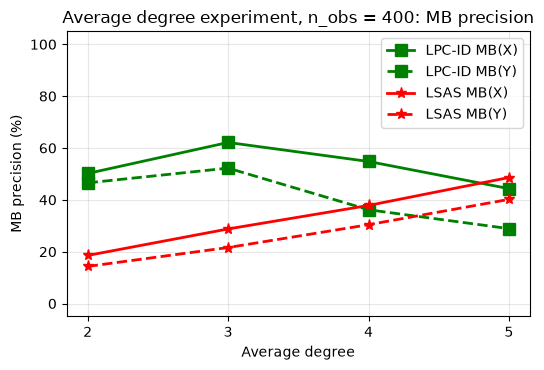

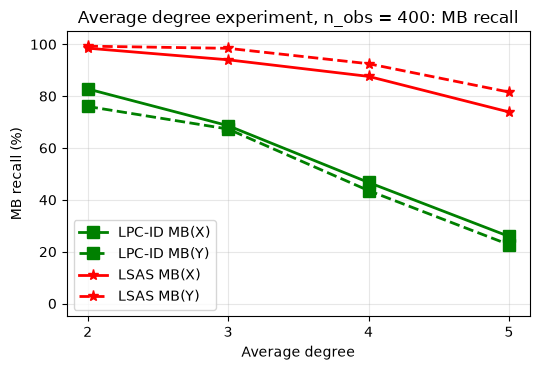

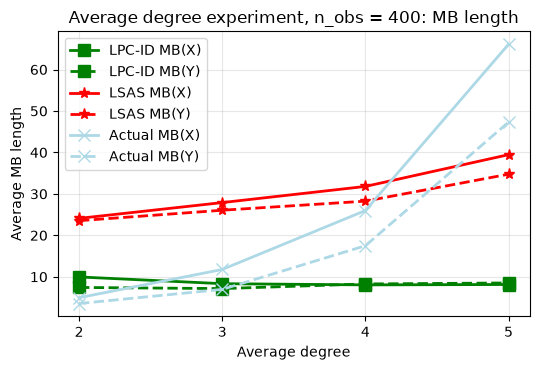

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,2,LPC-ID,X,200,9.960,6.981555,4.955,4.812356,0.501743,0.312695,0.827845,0.206170
1,2,LPC-ID,Y,200,7.425,5.793288,3.545,3.188859,0.465476,0.302268,0.760196,0.269671
2,2,LSAS,X,200,24.090,6.021895,4.955,4.812356,0.185481,0.123078,0.985073,0.078369
3,2,LSAS,Y,200,23.530,5.946081,3.545,3.188859,0.143168,0.095217,0.992820,0.041233
4,3,LPC-ID,X,200,8.335,4.898238,11.760,16.079338,0.621319,0.248794,0.686061,0.301539
5,3,LPC-ID,Y,200,7.150,4.124629,6.960,10.647311,0.522365,0.258107,0.673133,0.300113
6,3,LSAS,X,200,27.900,9.212729,11.760,16.079338,0.287733,0.175667,0.940210,0.155056
7,3,LSAS,Y,200,26.055,7.733109,6.960,10.647311,0.216025,0.149303,0.984466,0.086805
8,4,LPC-ID,X,200,8.045,3.934511,25.975,40.988715,0.548047,0.253736,0.467157,0.349440
9,4,LPC-ID,Y,200,8.270,4.028429,17.490,35.127476,0.361752,0.246798,0.435731,0.348000


In [74]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


## Nonlinearity Experiment


In [75]:
BASE_N_OBS = 100
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [76]:
beta_results_list = []

for beta_value in beta_values:
    results_one_beta = run_structure_experiment(
        structure_name=f"Nonlinearity experiment, beta={beta_value}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=BASE_P,
        beta=beta_value,
        ci_method=BASE_CI_METHOD,
        n_force_x_parents=N_FORCE_X_PARENTS,
        n_force_y_parents=N_FORCE_Y_PARENTS,
        max_z_size=MAX_Z_SIZE
        )
    results_one_beta["beta_value"] = beta_value
    beta_results_list.append(results_one_beta)

beta_results = pd.concat(beta_results_list, ignore_index=True)
beta_results


NameError: name 'N_FORCE_X_PARENTS' is not defined

In [ ]:
beta_decision_metrics = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

beta_decisive_metrics = (
    beta_results[beta_results["is_decisive"]]
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

beta_decision_metrics = beta_decision_metrics.merge(
    beta_decisive_metrics,
    on=["method", "beta_value"],
    how="left",
)

beta_decision_metrics["n_decisive"] = beta_decision_metrics["n_decisive"].fillna(0).astype(int)

beta_decision_metrics


In [ ]:
beta_effect_effort = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

beta_effect_effort


In [ ]:
plot_experiment_metrics(
    decision_df=beta_decision_metrics,
    effect_df=beta_effect_effort,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)


In [ ]:
beta_mb_comparison, beta_mb_comparison_detail = compare_markov_blankets(
    beta_results,
    group_cols=["beta_value"],
)

plot_markov_blanket_metrics(
    beta_mb_comparison,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)

beta_mb_comparison
